# Perspectiva — EDA for all datasets

Four topics: **Sputnik vaccine**, **Ukraine war**, **Brexit**, **Elon Musk**  
Schema per file: `date (str YYYY-MM-DD)`, `country_iso3 (str)`, `avg_tone (float|NaN)`, `article_count (uint32)`

Questions answered:
1. Which countries have the **most / least** coverage?
2. Which countries are the **most positive / most negative**?
3. Which countries **changed opinion the most / least** over time?
4. **Global sentiment** trajectory over time
5. **Country-level** sentiment trajectory (key countries)
6. **When** did major sentiment shifts happen?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e293b',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'figure.dpi':       130,
})

ORANGE  = '#C97432'
TEAL    = '#2dd4bf'
RED     = '#f87171'
GREEN   = '#4ade80'
BLUE    = '#60a5fa'
PURPLE  = '#a78bfa'
MUTED   = '#475569'

DATA_DIR = '../app/public/data'

DATASETS = {
    'Sputnik Vaccine':  'sputnik-vaccine-covid-2020-08-2021-08',
    'Ukraine War':      'ukraine-war-2022-02-2022-03',
    'Brexit':           'brexit-2015-01-2026-05',
    'Elon Musk':        'elon-musk-2015-01-2026-05',
}

dfs = {}
for name, slug in DATASETS.items():
    df = pd.read_parquet(f'{DATA_DIR}/{slug}.parquet')
    df['date'] = pd.to_datetime(df['date'])
    df['article_count'] = df['article_count'].astype(int)
    dfs[name] = df
    print(f"[{name}]  {len(df):,} rows  |  {df.country_iso3.nunique()} countries  |  "
          f"{df.date.nunique()} dates  |  {df.date.min().date()} → {df.date.max().date()}")

[Sputnik Vaccine]  30,888 rows  |  78 countries  |  396 dates  |  2020-08-01 → 2021-08-31
[Ukraine War]  1,890 rows  |  126 countries  |  15 dates  |  2022-02-24 → 2022-03-10
[Brexit]  636,740 rows  |  155 countries  |  4108 dates  |  2015-02-20 → 2026-05-20
[Elon Musk]  644,171 rows  |  157 countries  |  4103 dates  |  2015-02-25 → 2026-05-20


---
## 1  Dataset overview

In [2]:
for name, df in dfs.items():
    active = df[df.article_count > 0]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Total articles (all time) : {df.article_count.sum():>10,}")
    print(f"  Rows with coverage        : {len(active):>10,}  ({100*len(active)/len(df):.1f}%)")
    print(f"  Countries w/ any coverage : {active.country_iso3.nunique():>10}")
    print(f"  Avg tone (global mean)    : {active.avg_tone.mean():>10.3f}")
    print(f"  Avg tone (median)         : {active.avg_tone.median():>10.3f}")
    print(f"  Tone std-dev              : {active.avg_tone.std():>10.3f}")
    print(f"  Max articles on one day   : {df.article_count.max():>10,}")


  Sputnik Vaccine
  Total articles (all time) :      7,494
  Rows with coverage        :      2,298  (7.4%)
  Countries w/ any coverage :         78
  Avg tone (global mean)    :      0.122
  Avg tone (median)         :      0.009
  Tone std-dev              :      2.103
  Max articles on one day   :         65

  Ukraine War
  Total articles (all time) :    113,291
  Rows with coverage        :      1,456  (77.0%)
  Countries w/ any coverage :        126
  Avg tone (global mean)    :     -2.990
  Avg tone (median)         :     -3.050
  Tone std-dev              :      1.549
  Max articles on one day   :      2,585

  Brexit
  Total articles (all time) :  1,997,502
  Rows with coverage        :    111,655  (17.5%)
  Countries w/ any coverage :        155
  Avg tone (global mean)    :     -0.831
  Avg tone (median)         :     -0.849
  Tone std-dev              :      1.949
  Max articles on one day   :      7,169

  Elon Musk
  Total articles (all time) :    921,348
  Rows with cov

---
## 2  Coverage — most and least articles per country

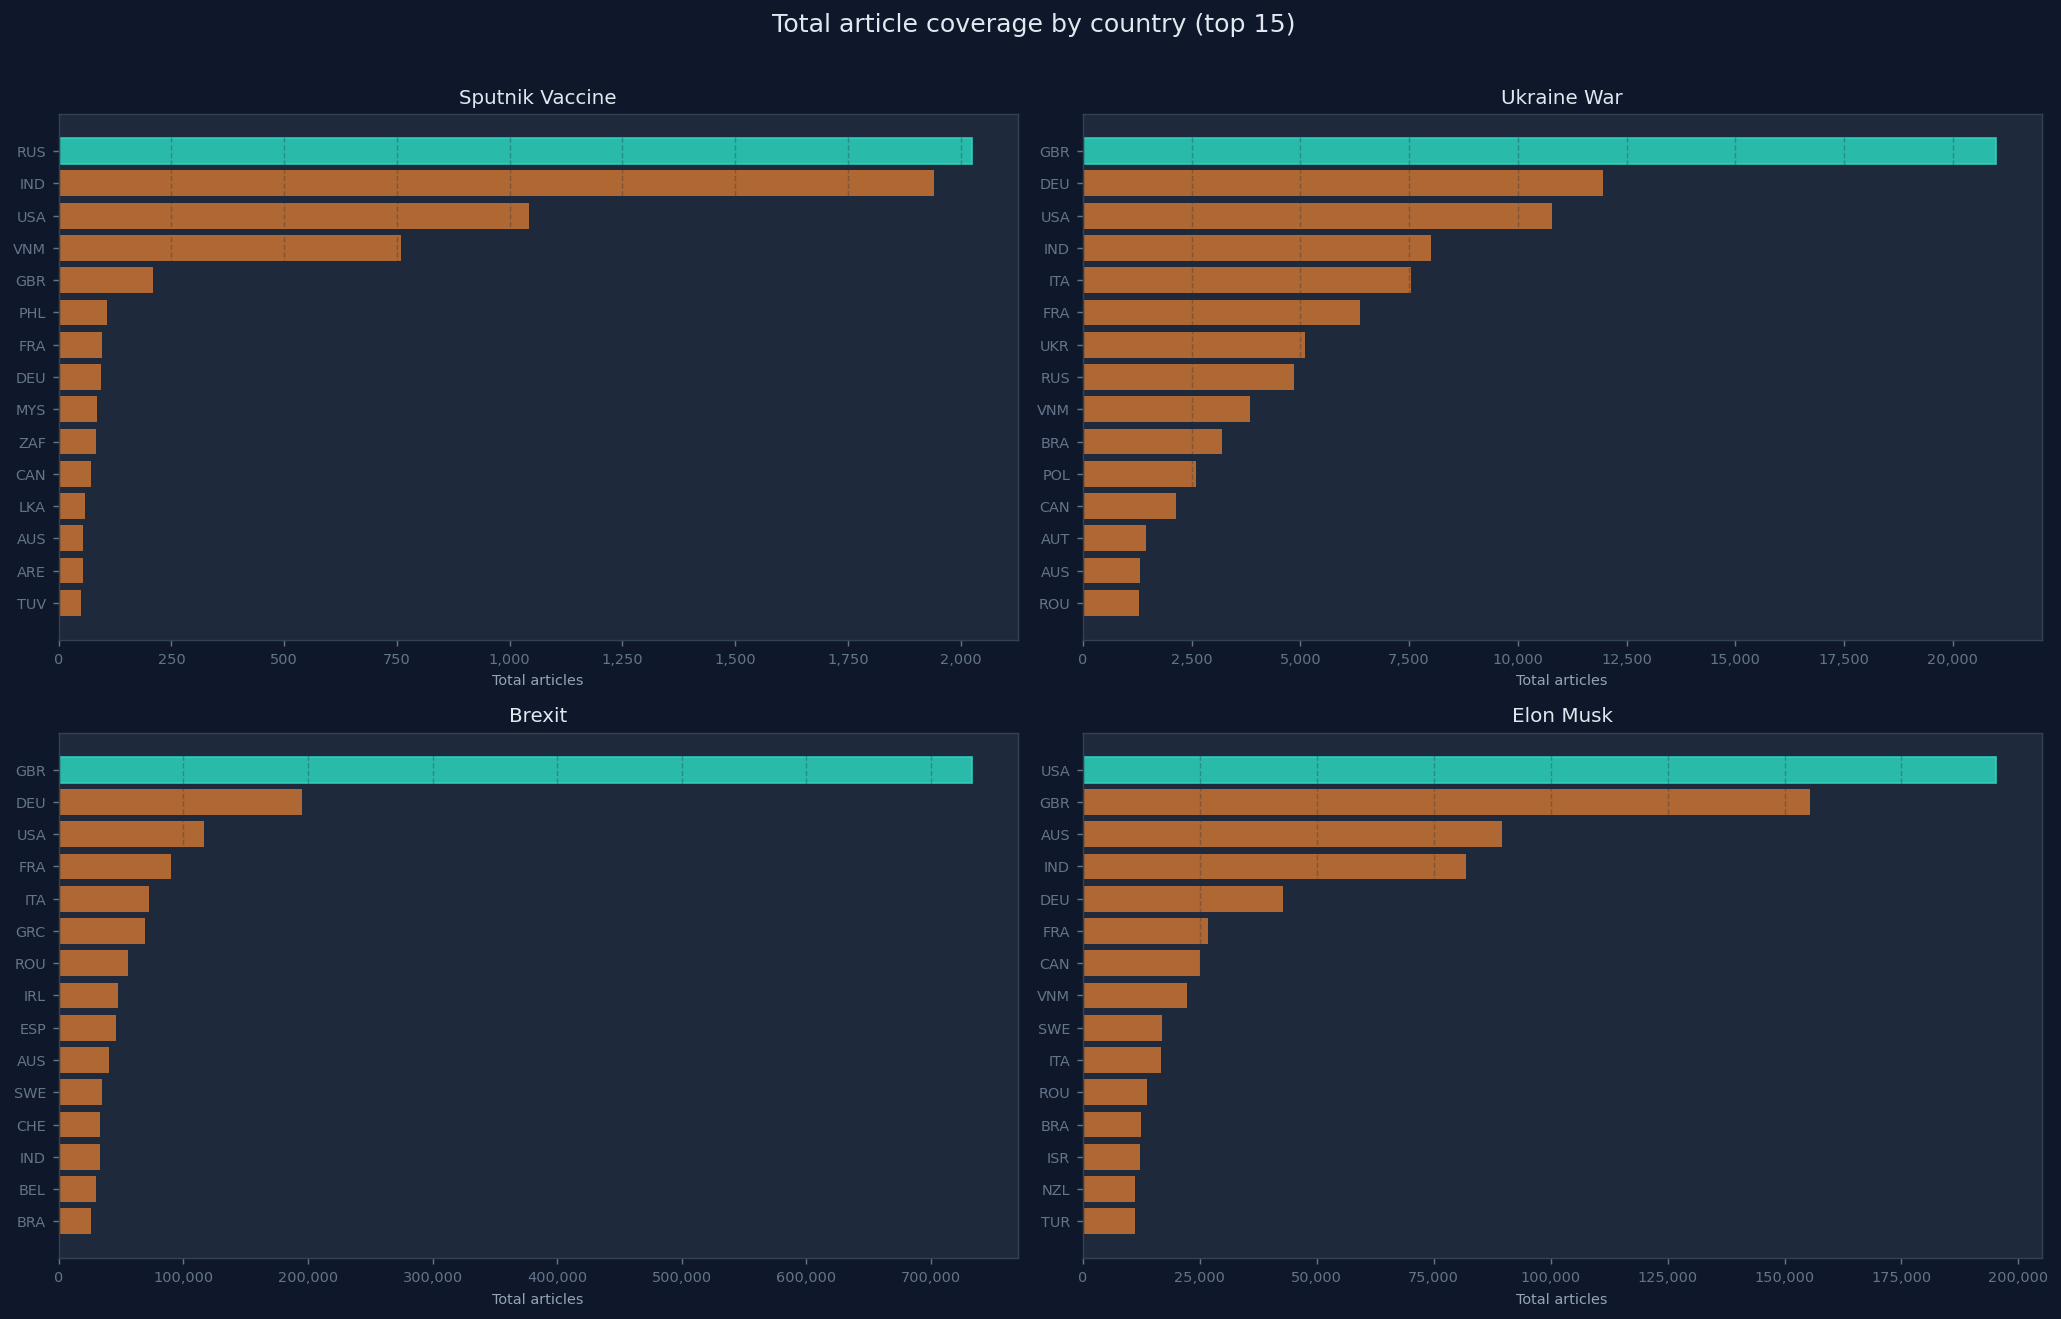

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Total article coverage by country (top 15)', fontsize=14, color='#e2e8f0', y=1.01)

for ax, (name, df) in zip(axes.flat, dfs.items()):
    top = (df.groupby('country_iso3')['article_count']
             .sum().sort_values(ascending=False).head(15))
    bars = ax.barh(top.index[::-1], top.values[::-1], color=ORANGE, alpha=0.85)
    # highlight top bar
    bars[-1].set_color(TEAL)
    ax.set_title(name, color='#e2e8f0', fontsize=11, pad=6)
    ax.set_xlabel('Total articles', fontsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

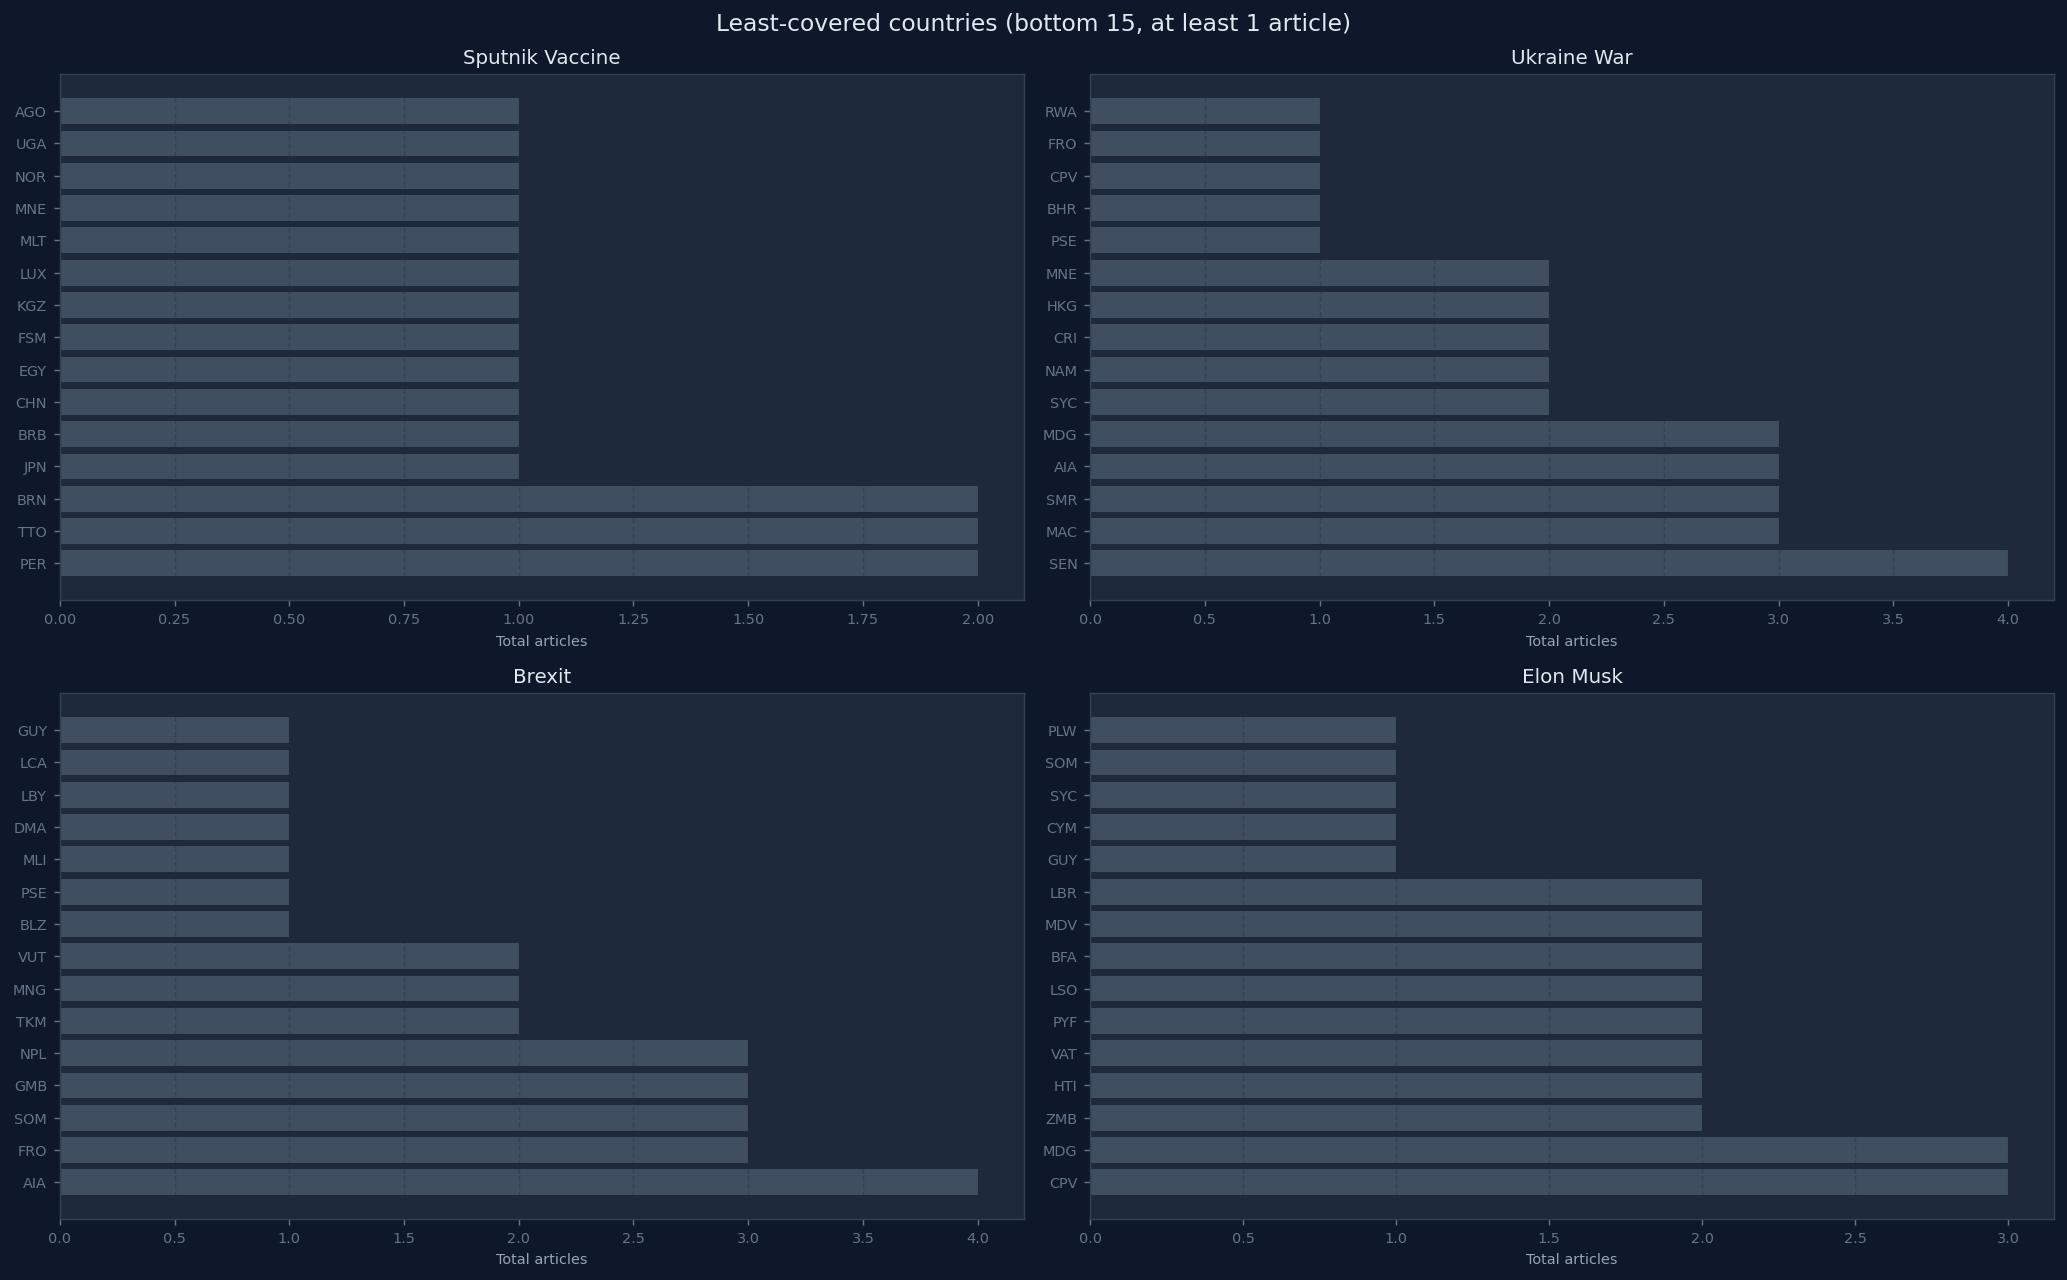

In [4]:
# Bottom 15 countries by coverage (with at least 1 article ever)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Least-covered countries (bottom 15, at least 1 article)', fontsize=13, color='#e2e8f0')

for ax, (name, df) in zip(axes.flat, dfs.items()):
    bottom = (df.groupby('country_iso3')['article_count']
                .sum()
                .pipe(lambda s: s[s > 0])
                .sort_values().head(15))
    ax.barh(bottom.index[::-1], bottom.values[::-1], color=MUTED, alpha=0.85)
    ax.set_title(name, color='#e2e8f0', fontsize=11, pad=6)
    ax.set_xlabel('Total articles', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3  Sentiment — most positive and most negative countries

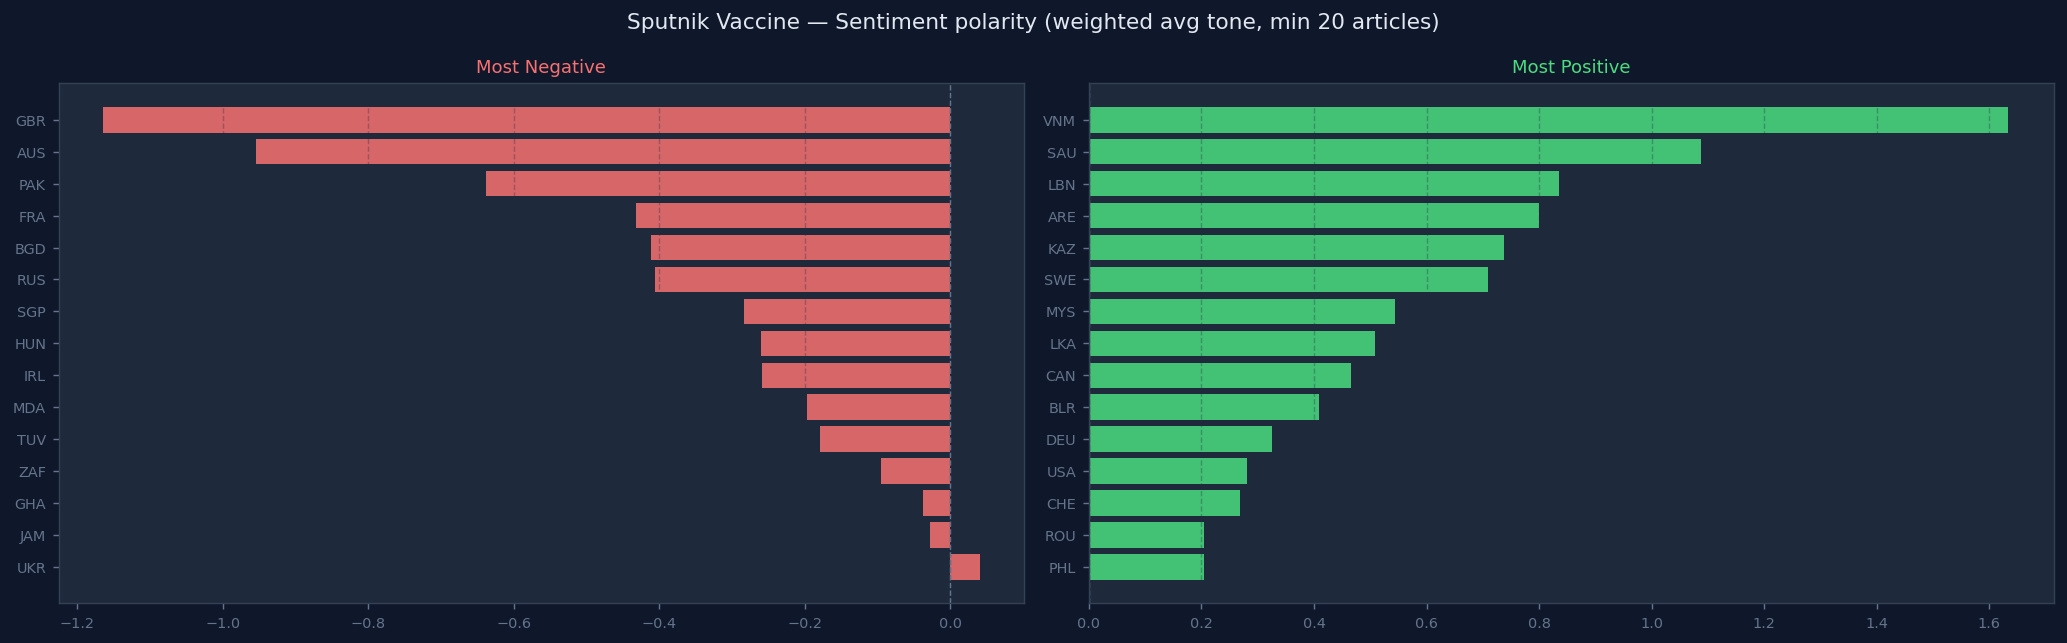


  [Sputnik Vaccine] Most negative: GBR  (-1.16)
  [Sputnik Vaccine] Most positive: VNM  (1.63)



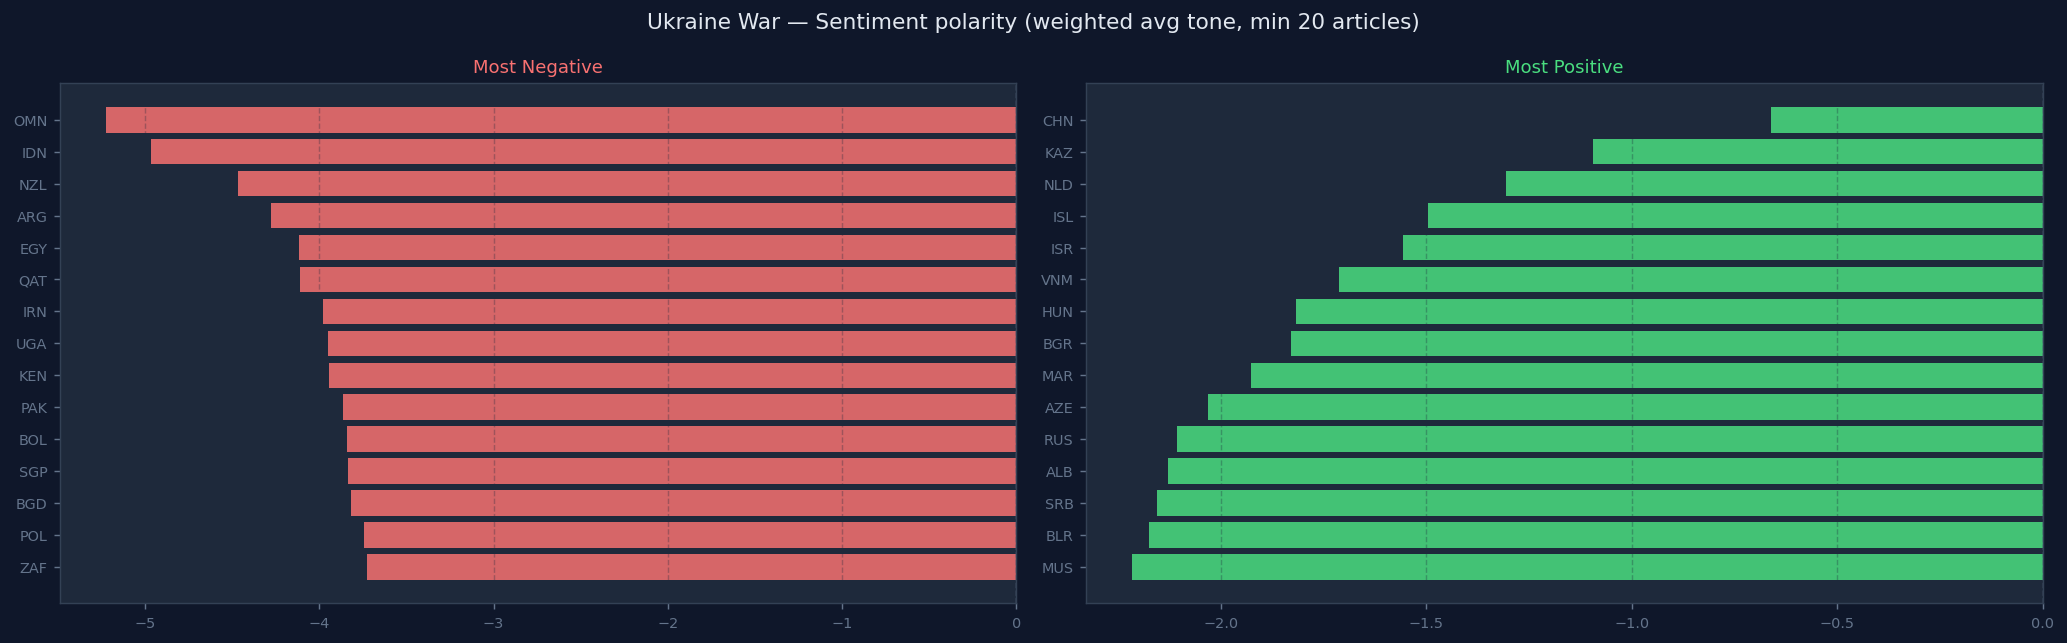


  [Ukraine War] Most negative: OMN  (-5.23)
  [Ukraine War] Most positive: CHN  (-0.66)



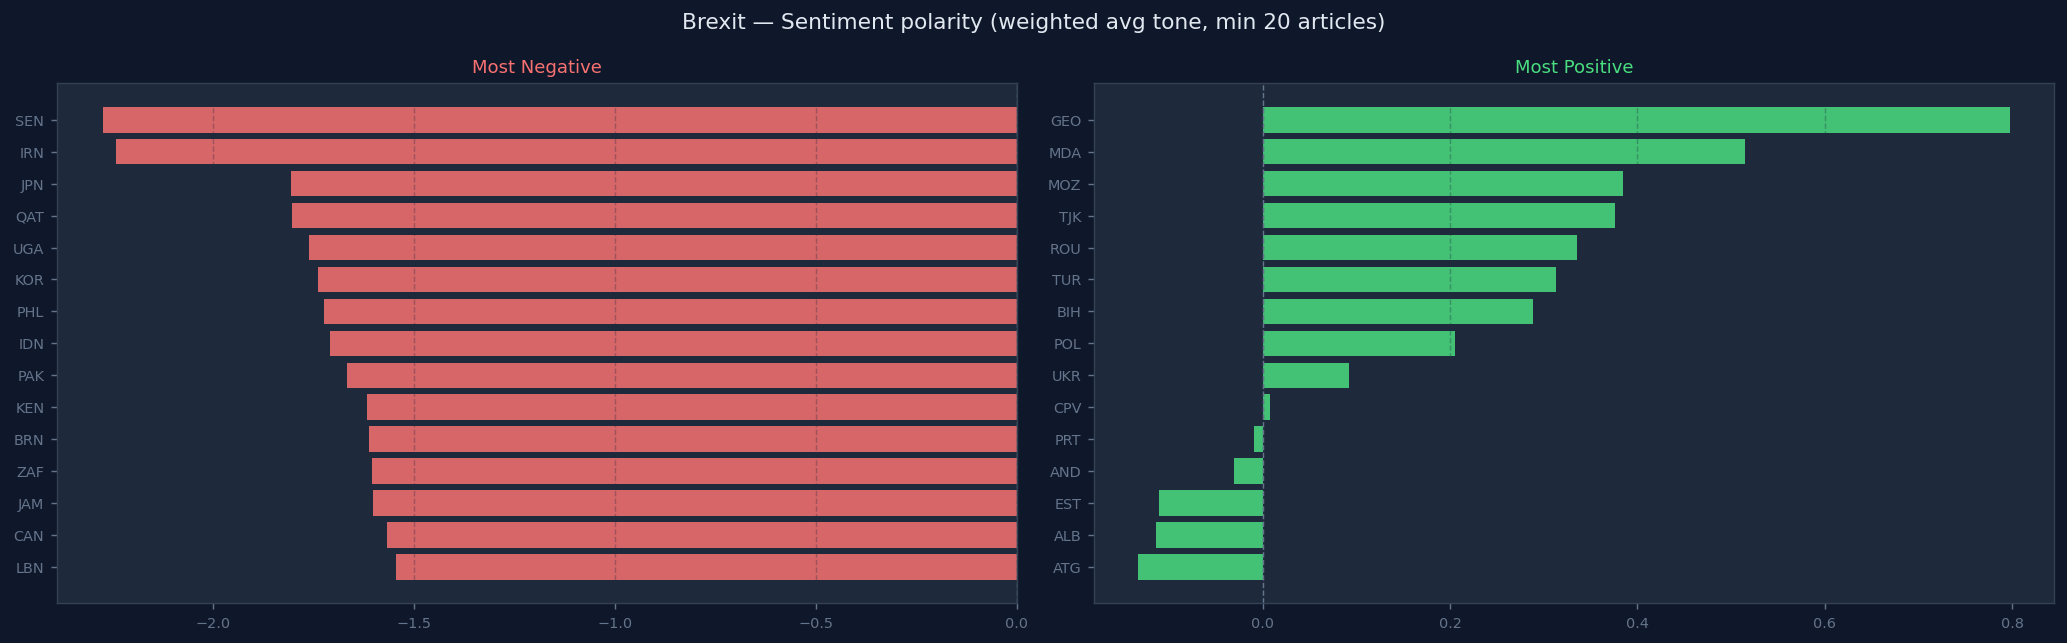


  [Brexit] Most negative: SEN  (-2.27)
  [Brexit] Most positive: GEO  (0.80)



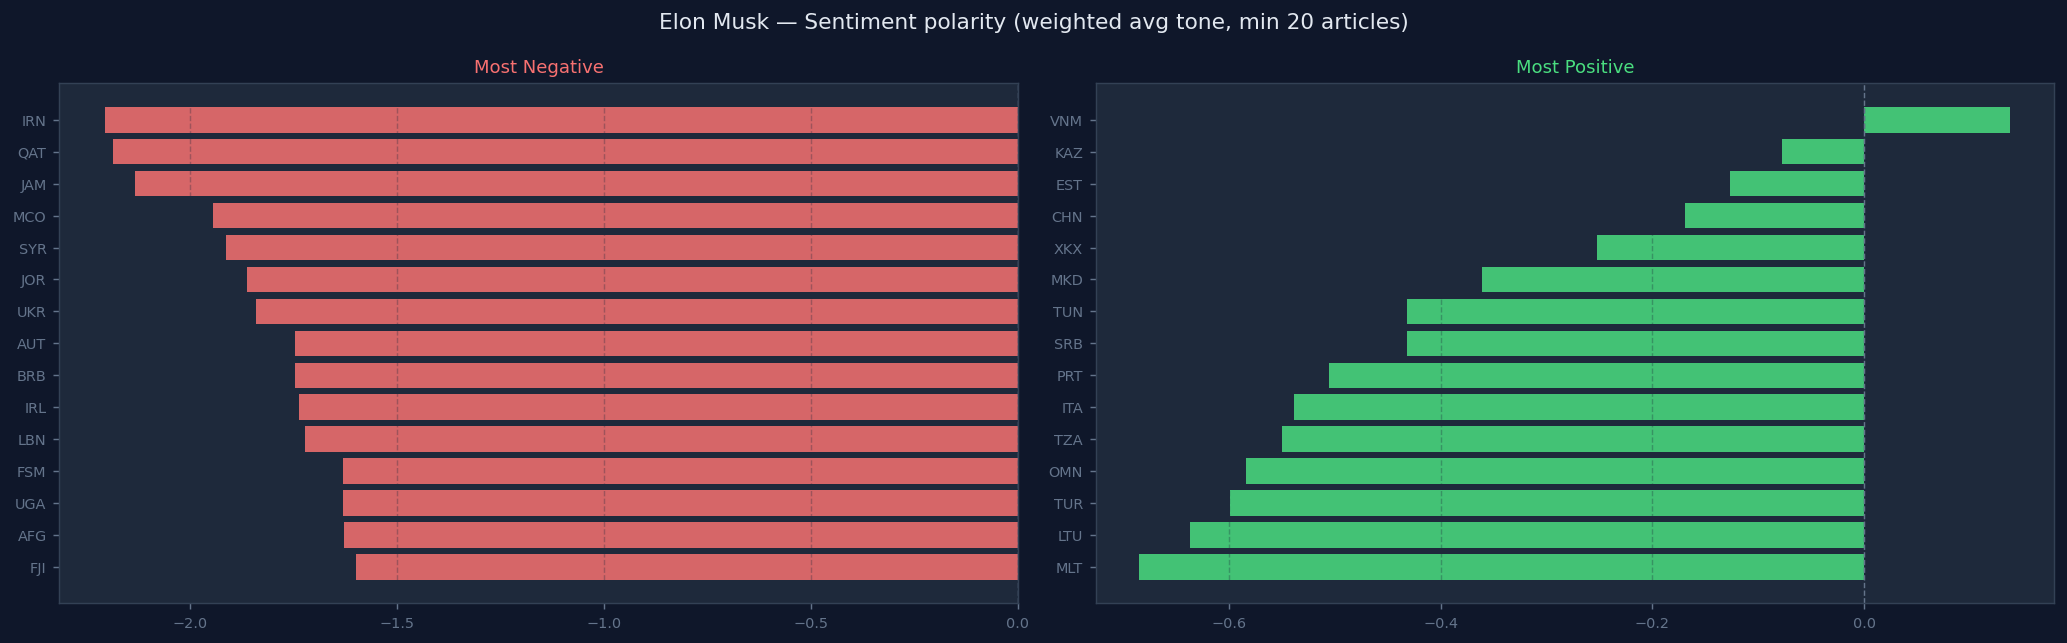


  [Elon Musk] Most negative: IRN  (-2.21)
  [Elon Musk] Most positive: VNM  (0.14)



In [5]:
MIN_ARTICLES = 20   # ignore countries with < N total articles (noise)

for name, df in dfs.items():
    active = df[df.article_count > 0].dropna(subset=['avg_tone'])
    # weighted average tone: weight by article_count
    country_stats = (active.groupby('country_iso3')
                           .apply(lambda g: pd.Series({
                               'total_articles': g.article_count.sum(),
                               'wavg_tone': np.average(g.avg_tone, weights=g.article_count),
                               'tone_std':  g.avg_tone.std(),
                               'tone_min':  g.avg_tone.min(),
                               'tone_max':  g.avg_tone.max(),
                               'days_covered': len(g),
                           }))
                           .query(f'total_articles >= {MIN_ARTICLES}')
                           .sort_values('wavg_tone'))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{name} — Sentiment polarity (weighted avg tone, min {MIN_ARTICLES} articles)',
                 color='#e2e8f0', fontsize=12)

    # Most negative
    neg = country_stats.head(15)
    axes[0].barh(neg.index[::-1], neg.wavg_tone[::-1], color=RED, alpha=0.85)
    axes[0].set_title('Most Negative', color=RED, fontsize=10)
    axes[0].axvline(0, color='#64748b', linewidth=0.8, linestyle='--')
    axes[0].tick_params(labelsize=8)
    axes[0].grid(axis='x', alpha=0.3)

    # Most positive
    pos = country_stats.tail(15)
    axes[1].barh(pos.index, pos.wavg_tone, color=GREEN, alpha=0.85)
    axes[1].set_title('Most Positive', color=GREEN, fontsize=10)
    axes[1].axvline(0, color='#64748b', linewidth=0.8, linestyle='--')
    axes[1].tick_params(labelsize=8)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print()
    print(f"  [{name}] Most negative: {country_stats.index[0]}  ({country_stats.wavg_tone.iloc[0]:.2f})")
    print(f"  [{name}] Most positive: {country_stats.index[-1]}  ({country_stats.wavg_tone.iloc[-1]:.2f})")
    print()

---
## 4  Opinion volatility — which countries changed the most / least

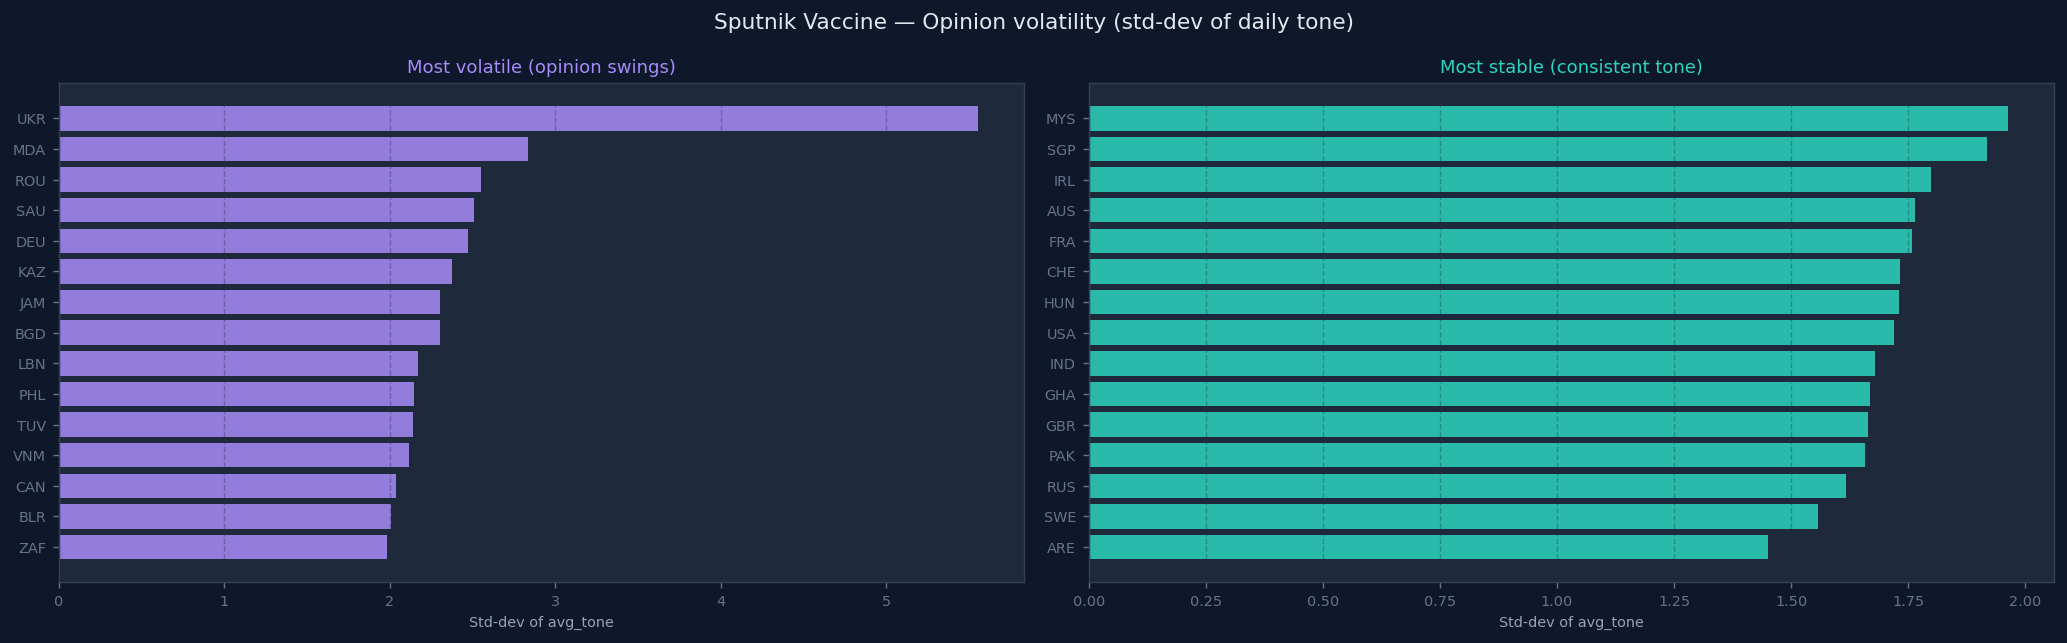

  [Sputnik Vaccine] Most volatile : UKR  (std=5.56, range=30.71)
  [Sputnik Vaccine] Most stable   : ARE  (std=1.45)



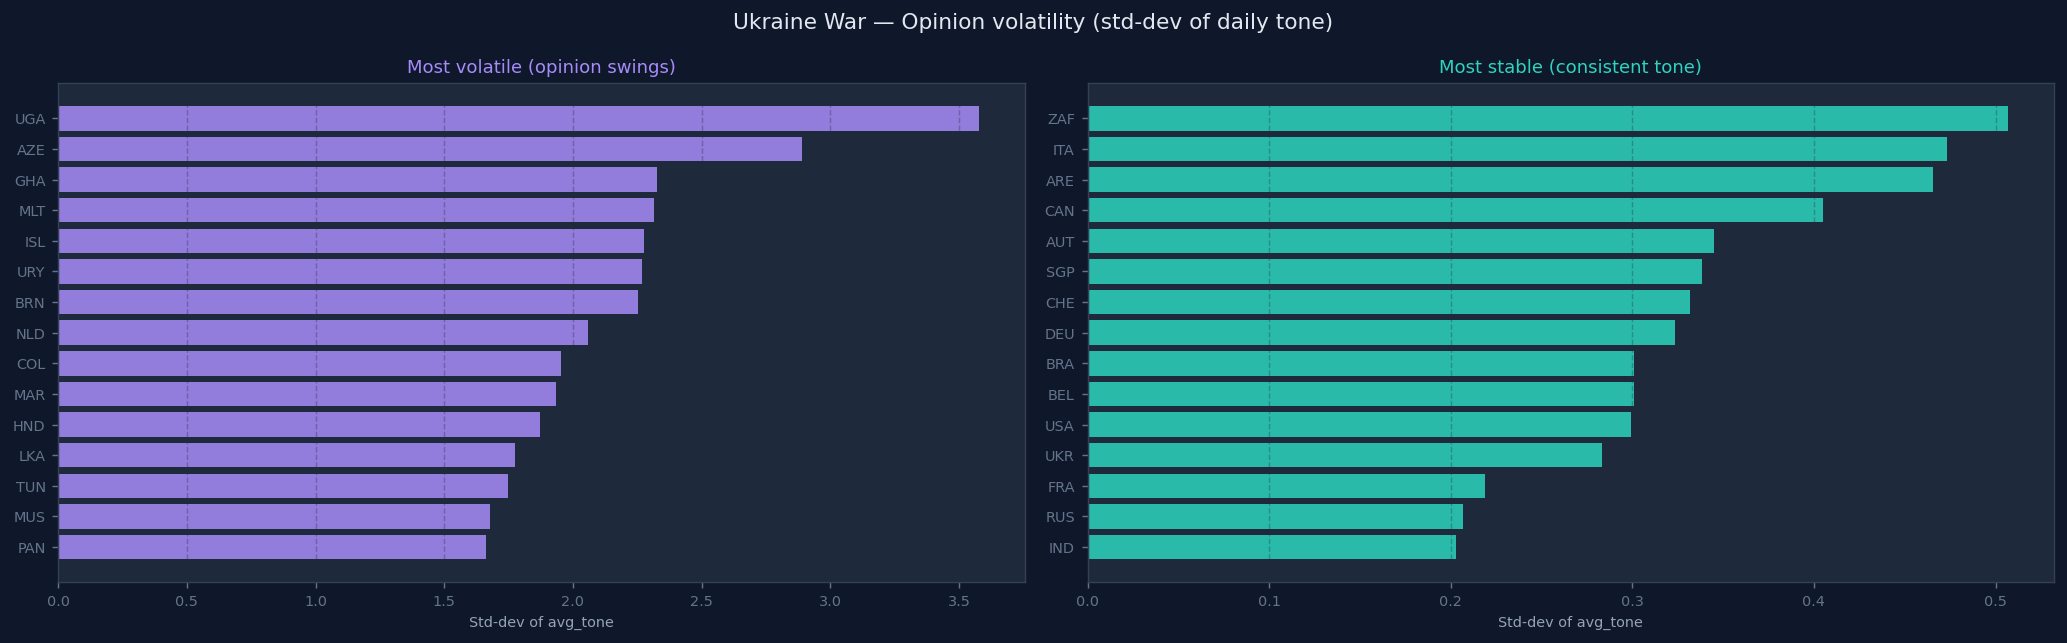

  [Ukraine War] Most volatile : UGA  (std=3.58, range=12.54)
  [Ukraine War] Most stable   : IND  (std=0.20)



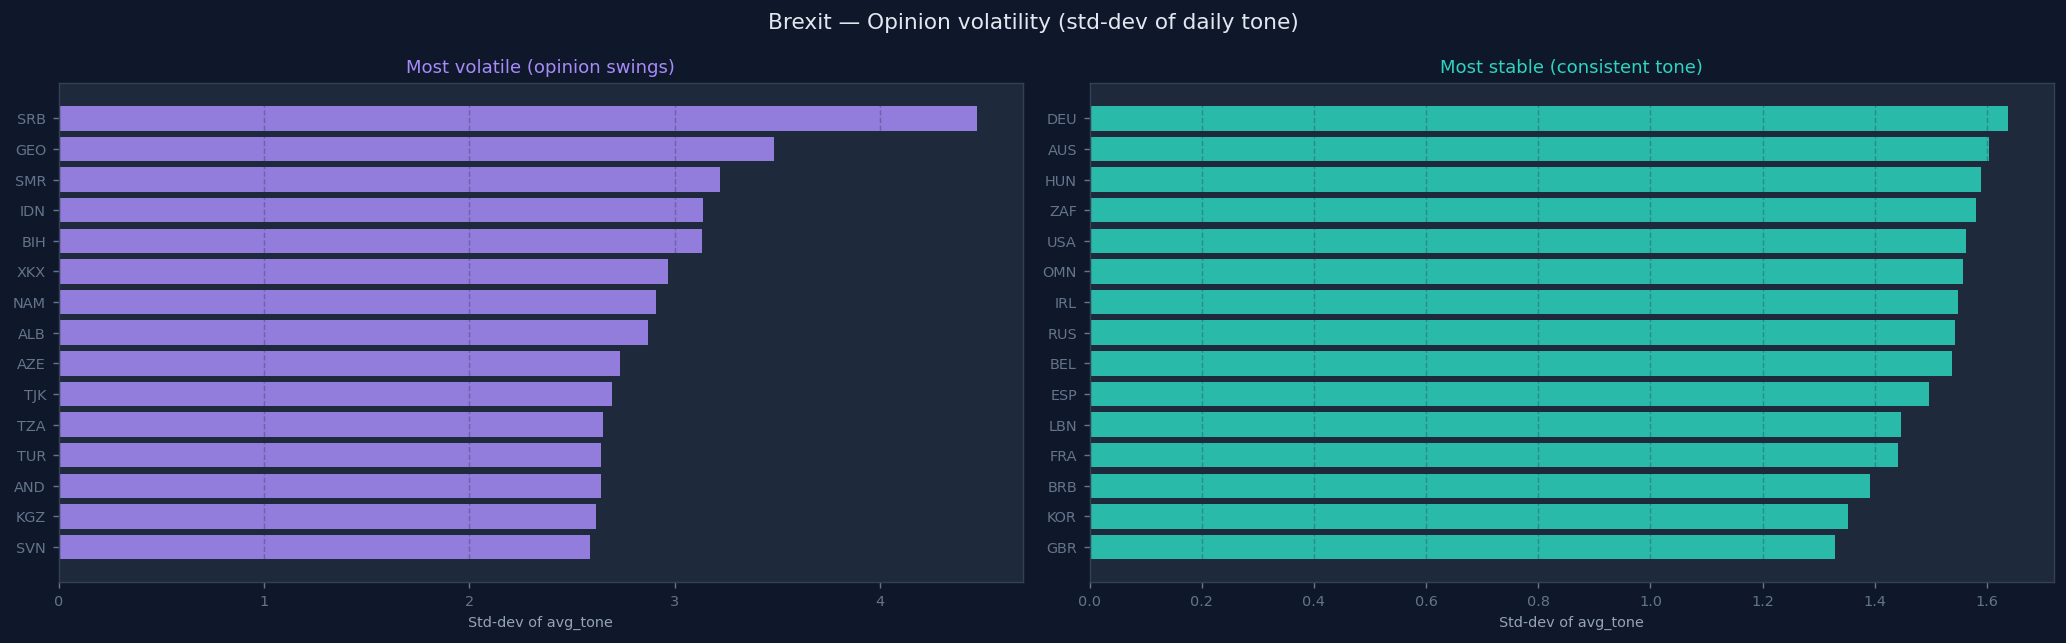

  [Brexit] Most volatile : SRB  (std=4.47, range=28.95)
  [Brexit] Most stable   : GBR  (std=1.33)



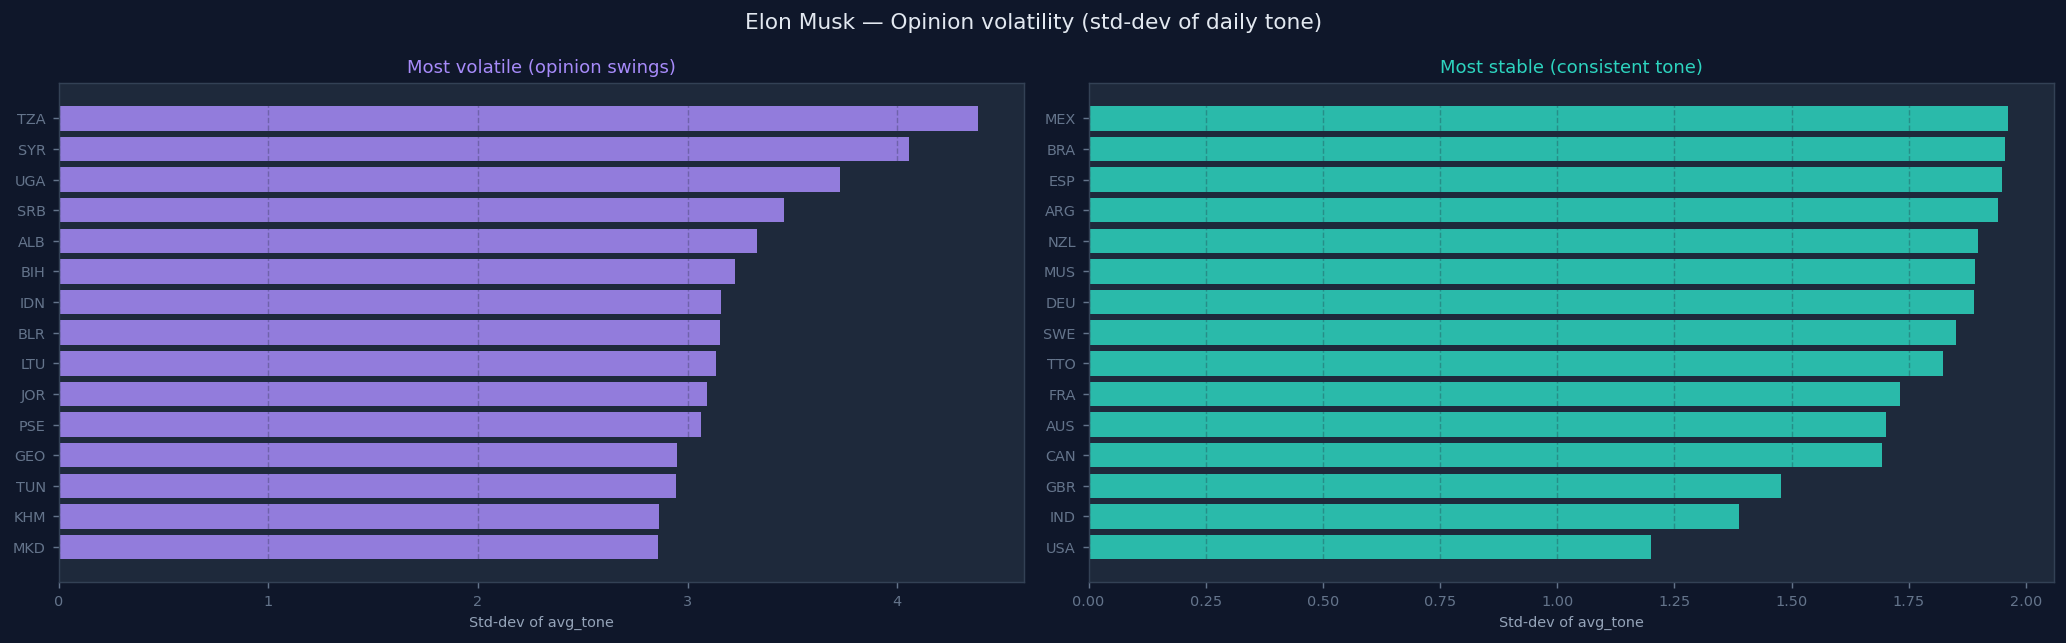

  [Elon Musk] Most volatile : TZA  (std=4.39, range=20.06)
  [Elon Musk] Most stable   : USA  (std=1.20)



In [6]:
MIN_DAYS = 5  # need at least N days of coverage to measure volatility

for name, df in dfs.items():
    active = df[(df.article_count > 0)].dropna(subset=['avg_tone'])
    vol = (active.groupby('country_iso3')
                 .agg(
                     days=('date', 'nunique'),
                     tone_std=('avg_tone', 'std'),
                     tone_range=('avg_tone', lambda x: x.max() - x.min()),
                     total_articles=('article_count', 'sum'),
                 )
                 .query(f'days >= {MIN_DAYS} and total_articles >= {MIN_ARTICLES}')
                 .sort_values('tone_std', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{name} — Opinion volatility (std-dev of daily tone)',
                 color='#e2e8f0', fontsize=12)

    # Most volatile
    top = vol.head(15)
    axes[0].barh(top.index[::-1], top.tone_std[::-1], color=PURPLE, alpha=0.85)
    axes[0].set_title('Most volatile (opinion swings)', color=PURPLE, fontsize=10)
    axes[0].set_xlabel('Std-dev of avg_tone', fontsize=8)
    axes[0].tick_params(labelsize=8)
    axes[0].grid(axis='x', alpha=0.3)

    # Least volatile (stable)
    bot = vol.tail(15)
    axes[1].barh(bot.index[::-1], bot.tone_std[::-1], color=TEAL, alpha=0.85)
    axes[1].set_title('Most stable (consistent tone)', color=TEAL, fontsize=10)
    axes[1].set_xlabel('Std-dev of avg_tone', fontsize=8)
    axes[1].tick_params(labelsize=8)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"  [{name}] Most volatile : {vol.index[0]}  (std={vol.tone_std.iloc[0]:.2f}, range={vol.tone_range.iloc[0]:.2f})")
    print(f"  [{name}] Most stable   : {vol.index[-1]}  (std={vol.tone_std.iloc[-1]:.2f})")
    print()

---
## 5  Global sentiment trajectory over time

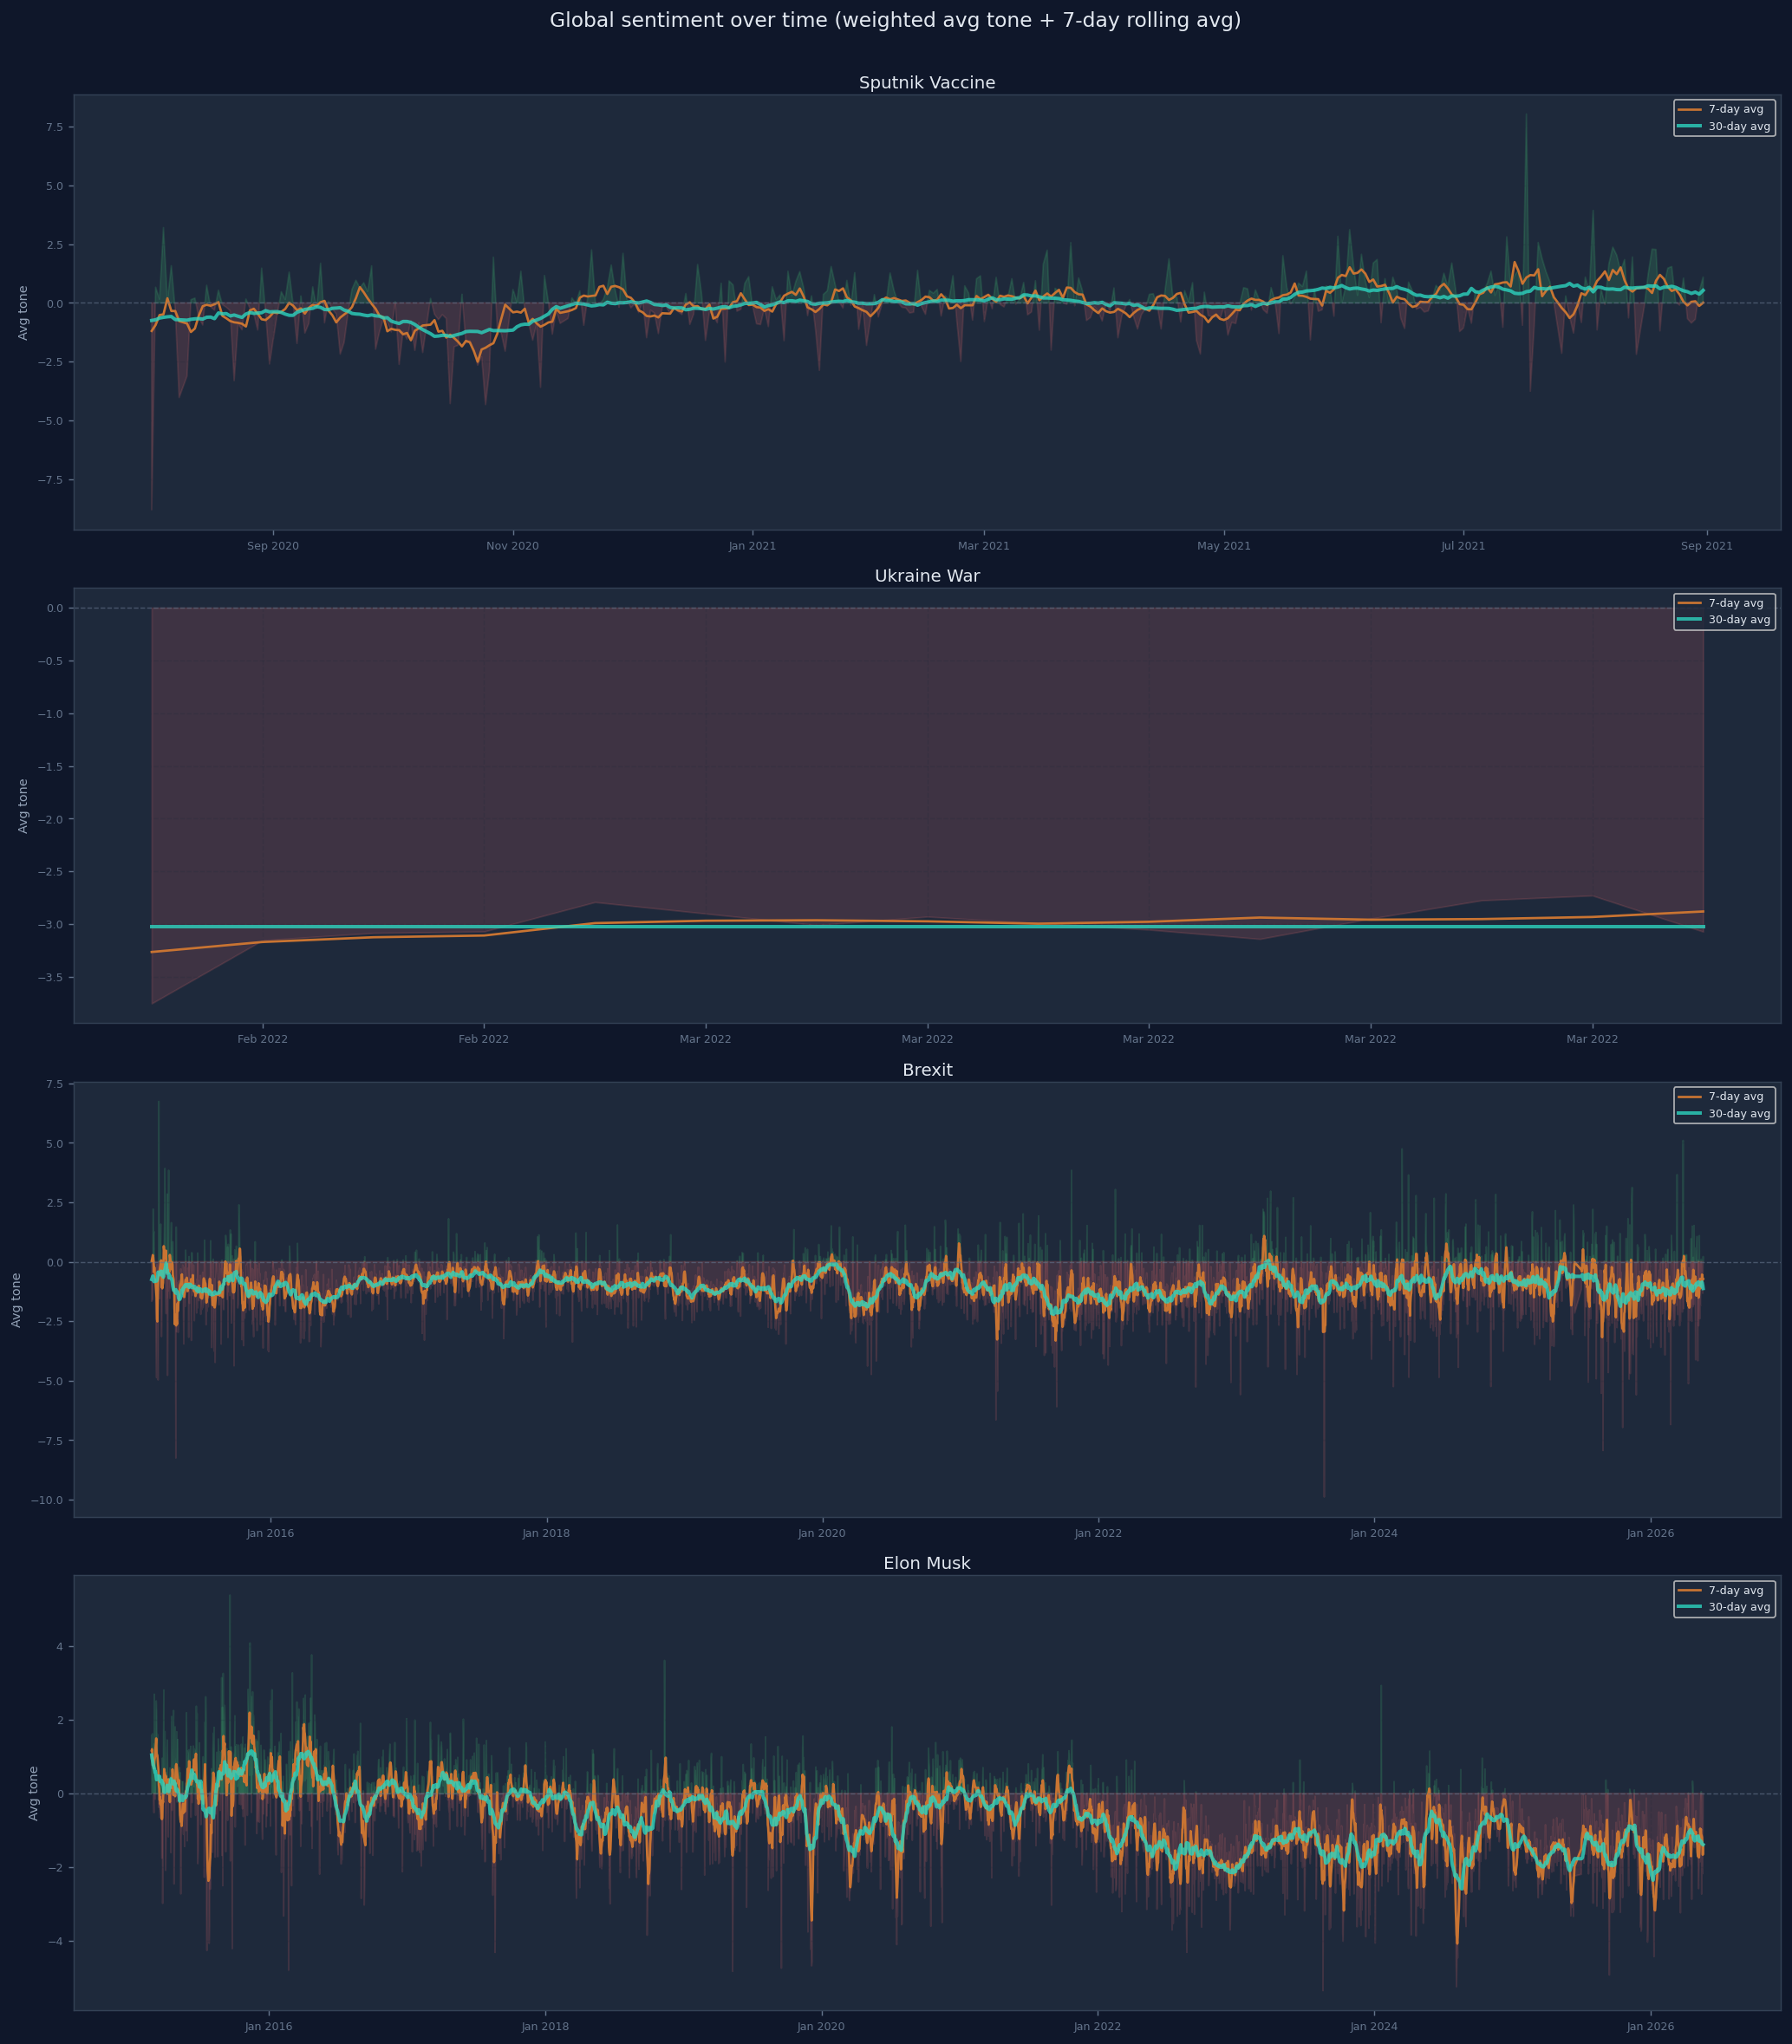

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle('Global sentiment over time (weighted avg tone + 7-day rolling avg)',
             color='#e2e8f0', fontsize=13, y=1.005)

for ax, (name, df) in zip(axes, dfs.items()):
    active = df[(df.article_count > 0)].dropna(subset=['avg_tone'])
    daily = (active.groupby('date')
                   .apply(lambda g: np.average(g.avg_tone, weights=g.article_count))
                   .reset_index(name='wavg_tone')
                   .sort_values('date'))
    daily['rolling7'] = daily.wavg_tone.rolling(7, center=True, min_periods=1).mean()
    daily['rolling30'] = daily.wavg_tone.rolling(30, center=True, min_periods=1).mean()

    ax.fill_between(daily.date, daily.wavg_tone, 0,
                    where=daily.wavg_tone >= 0, color=GREEN, alpha=0.15, interpolate=True)
    ax.fill_between(daily.date, daily.wavg_tone, 0,
                    where=daily.wavg_tone < 0,  color=RED,   alpha=0.15, interpolate=True)
    ax.plot(daily.date, daily.rolling7,  color=ORANGE, linewidth=1.5, label='7-day avg')
    ax.plot(daily.date, daily.rolling30, color=TEAL,   linewidth=2.2, label='30-day avg', alpha=0.8)
    ax.axhline(0, color='#64748b', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(name, color='#e2e8f0', fontsize=11, pad=4)
    ax.set_ylabel('Avg tone', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 6  Country-level sentiment trajectory (key countries per topic)

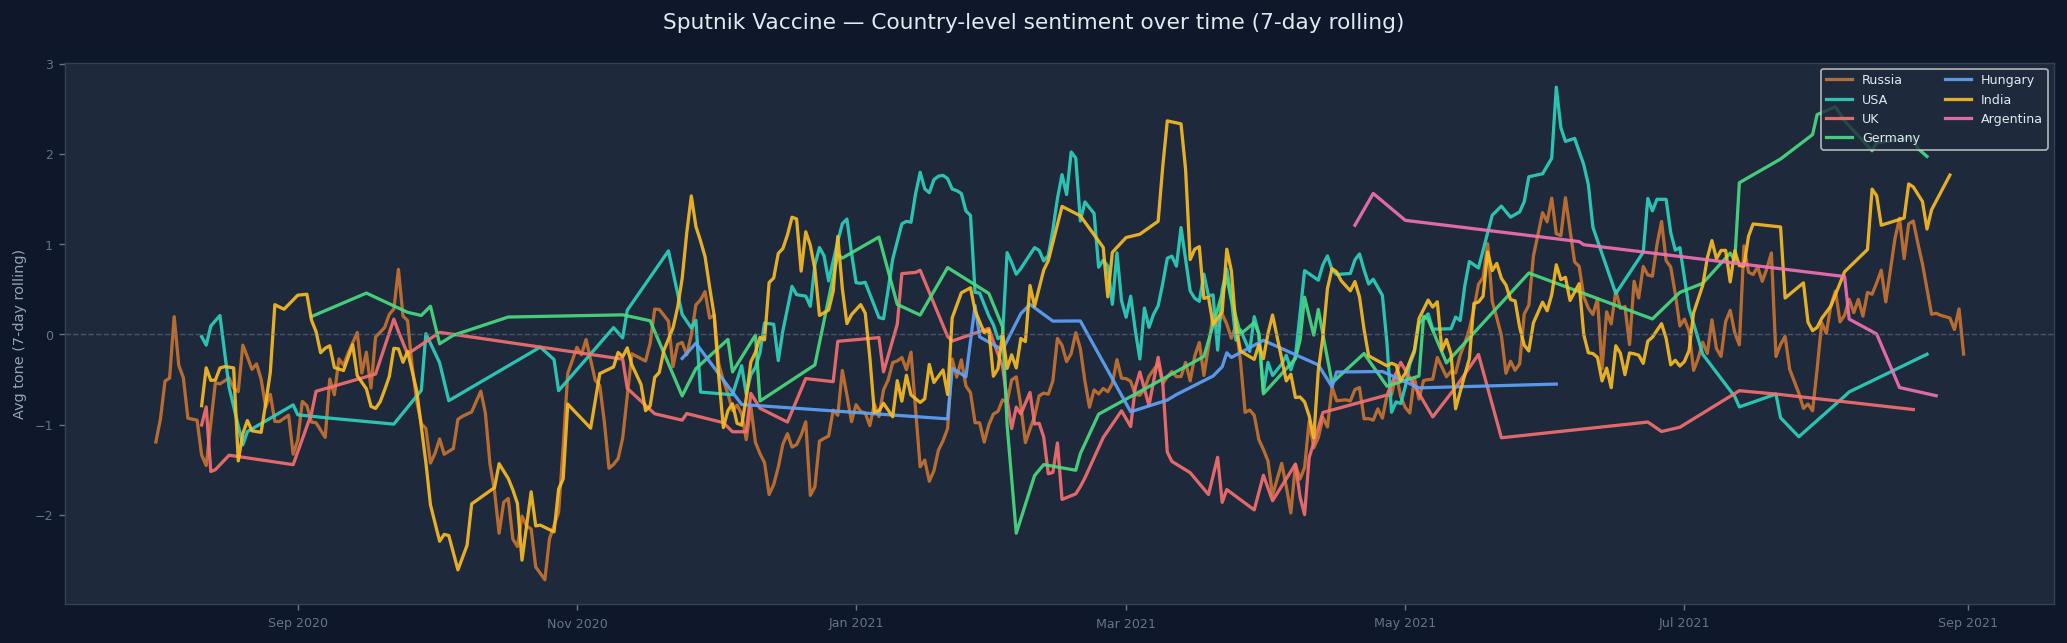

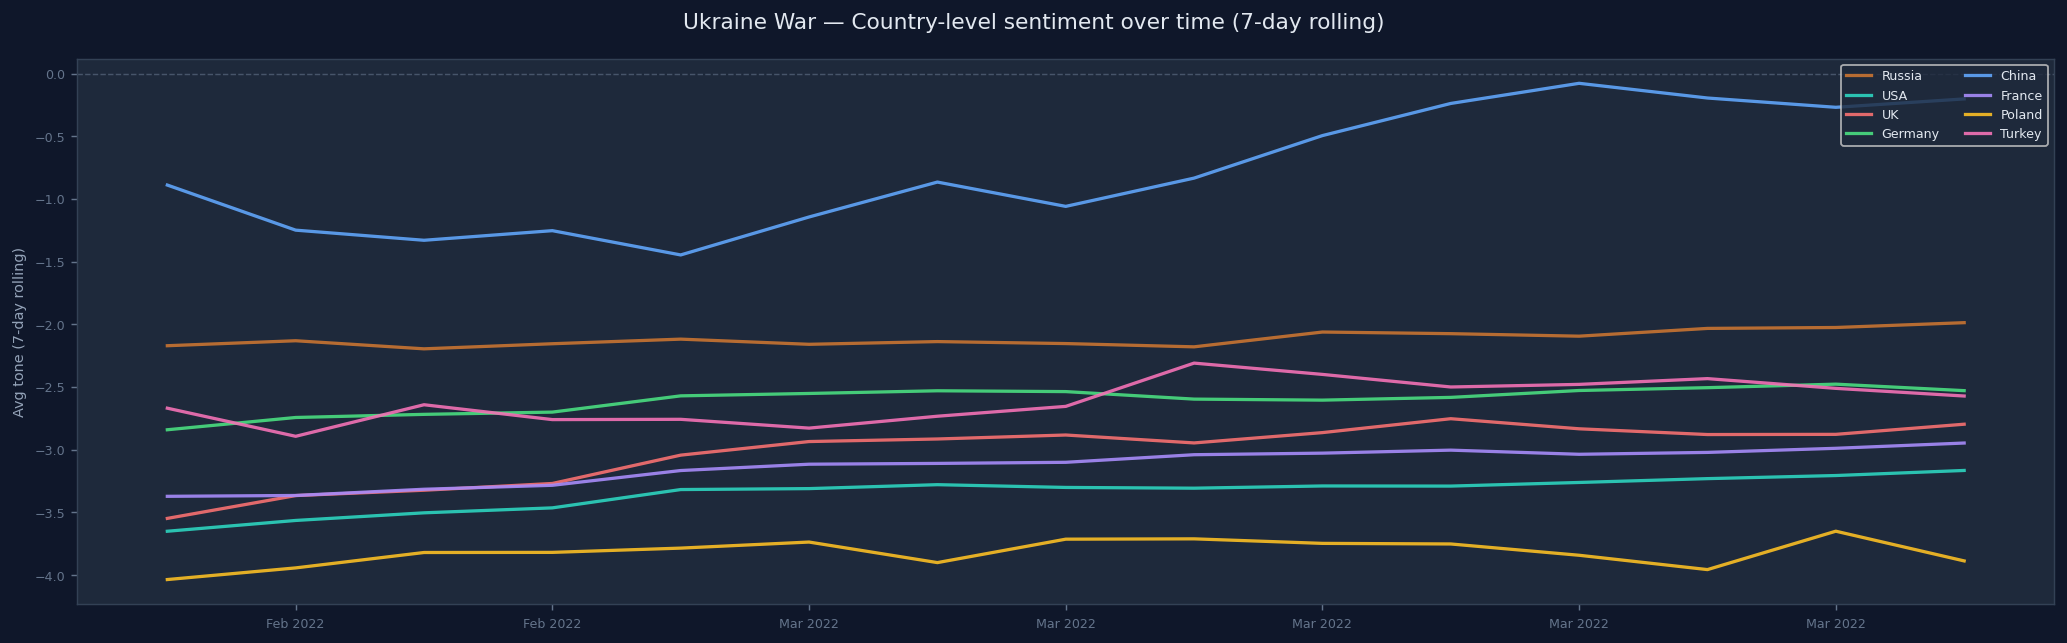

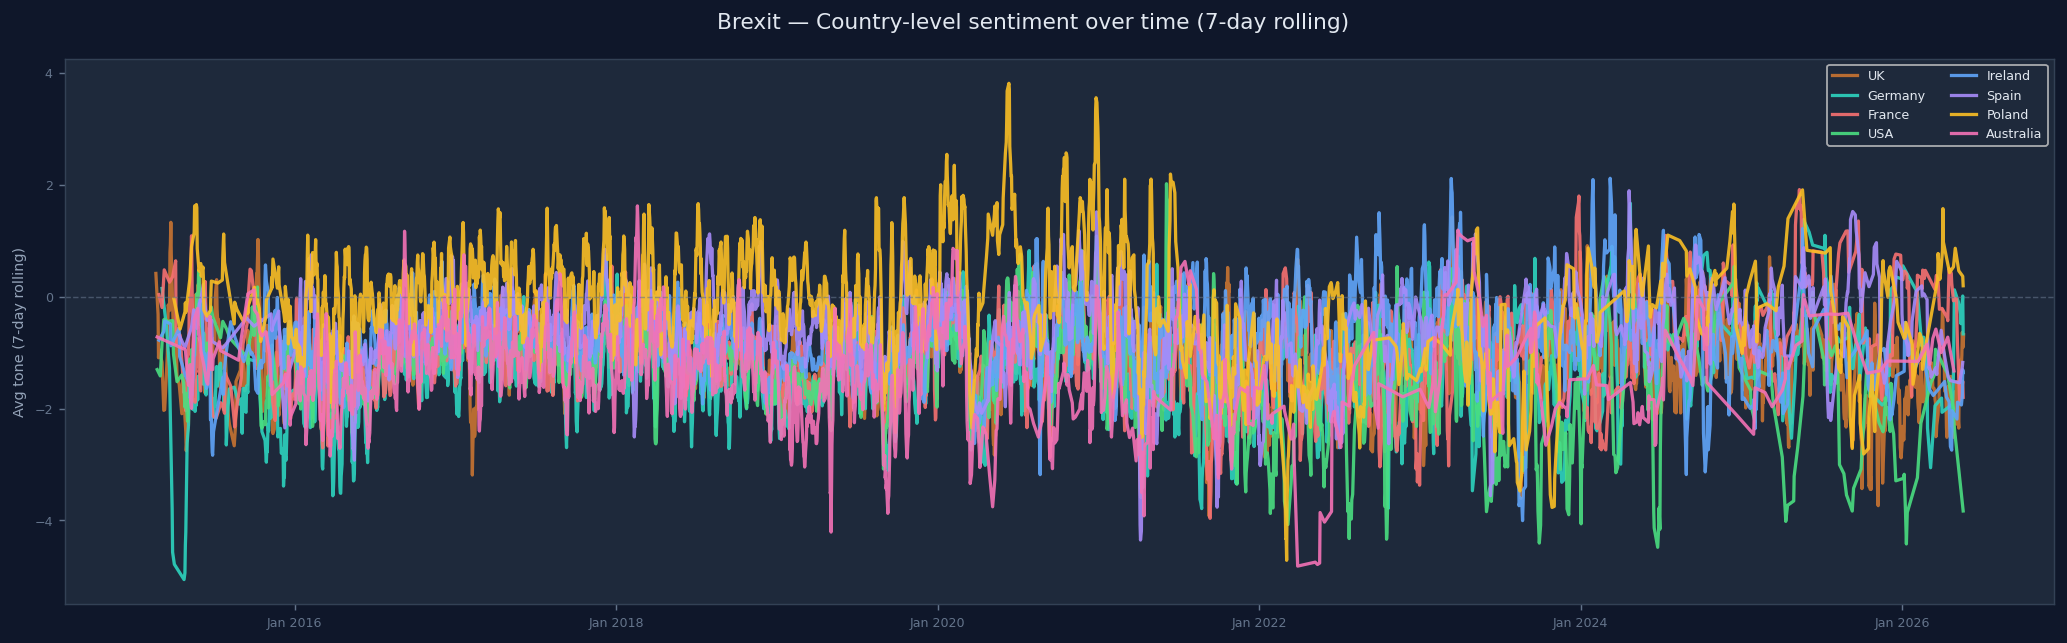

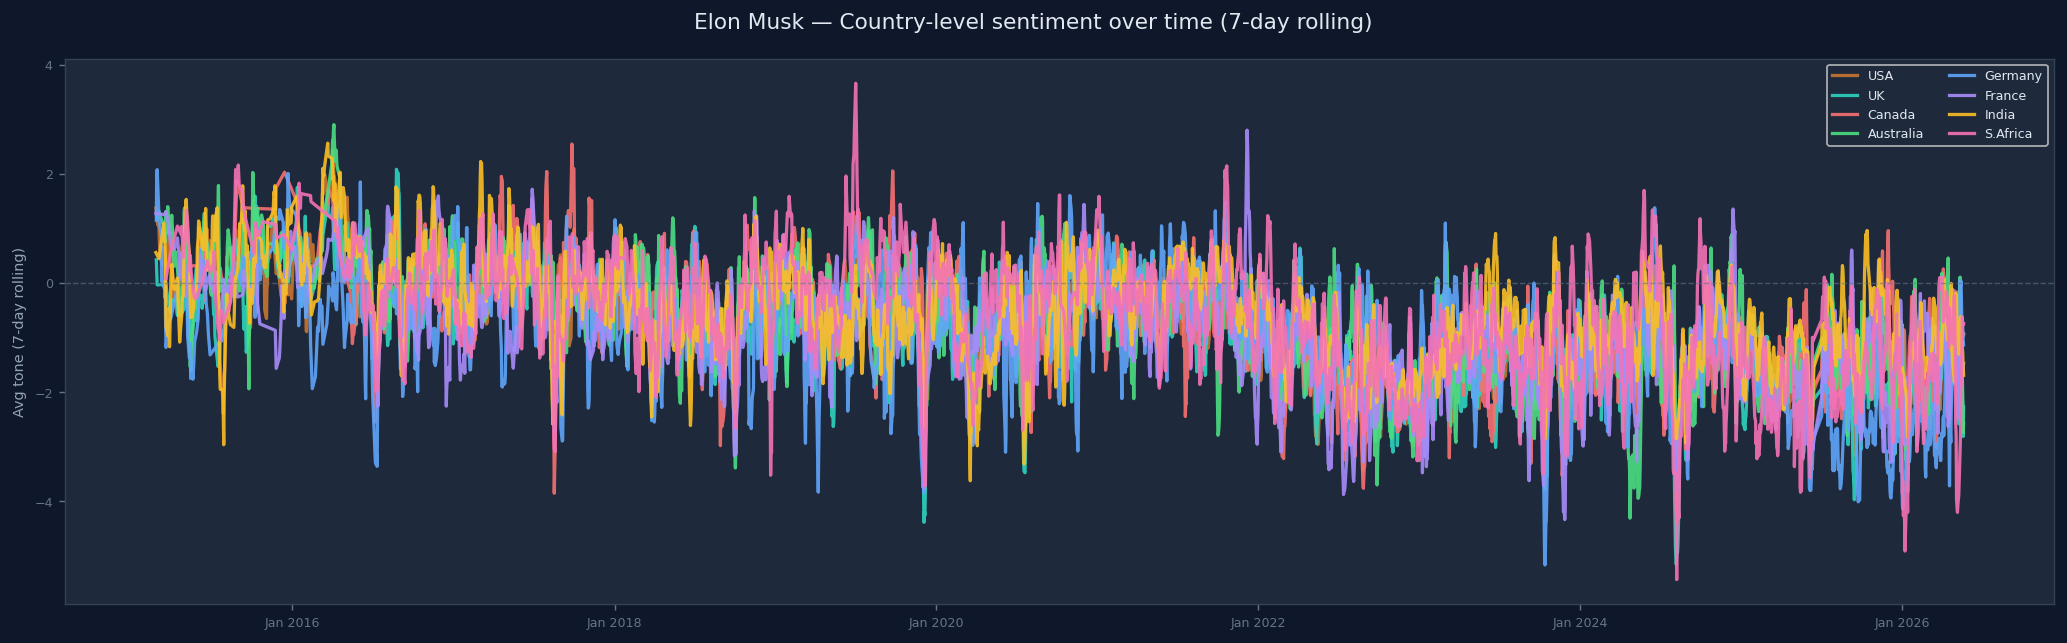

In [8]:
KEY_COUNTRIES = {
    'Sputnik Vaccine': ['RUS', 'USA', 'GBR', 'DEU', 'HUN', 'BRA', 'IND', 'ARG'],
    'Ukraine War':     ['RUS', 'USA', 'GBR', 'DEU', 'CHN', 'FRA', 'POL', 'TUR'],
    'Brexit':          ['GBR', 'DEU', 'FRA', 'USA', 'IRL', 'ESP', 'POL', 'AUS'],
    'Elon Musk':       ['USA', 'GBR', 'CAN', 'AUS', 'DEU', 'FRA', 'IND', 'ZAF'],
}

COUNTRY_NAMES = {
    'RUS':'Russia','USA':'USA','GBR':'UK','DEU':'Germany','HUN':'Hungary',
    'BRA':'Brazil','IND':'India','ARG':'Argentina','CHN':'China','FRA':'France',
    'POL':'Poland','TUR':'Turkey','IRL':'Ireland','ESP':'Spain','AUS':'Australia',
    'CAN':'Canada','ZAF':'S.Africa',
}

colors_palette = [ORANGE, TEAL, RED, GREEN, BLUE, PURPLE, '#fbbf24', '#f472b6']

for name, df in dfs.items():
    countries = KEY_COUNTRIES[name]
    active = df[(df.article_count > 0) & (df.country_iso3.isin(countries))].dropna(subset=['avg_tone'])

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.suptitle(f'{name} — Country-level sentiment over time (7-day rolling)',
                 color='#e2e8f0', fontsize=12)

    for iso, color in zip(countries, colors_palette):
        sub = active[active.country_iso3 == iso].sort_values('date')
        if len(sub) < 3:
            continue
        roll = sub.set_index('date')['avg_tone'].rolling(7, center=True, min_periods=1).mean()
        label = COUNTRY_NAMES.get(iso, iso)
        ax.plot(roll.index, roll.values, color=color, linewidth=1.8, label=label, alpha=0.9)

    ax.axhline(0, color='#64748b', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_ylabel('Avg tone (7-day rolling)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

---
## 7  Sentiment shift detection — when did opinion change?

Method: compute the 30-day rolling mean, then find dates where the **day-over-day change in the rolling mean** is in the top/bottom 5% — these are structural turning points.

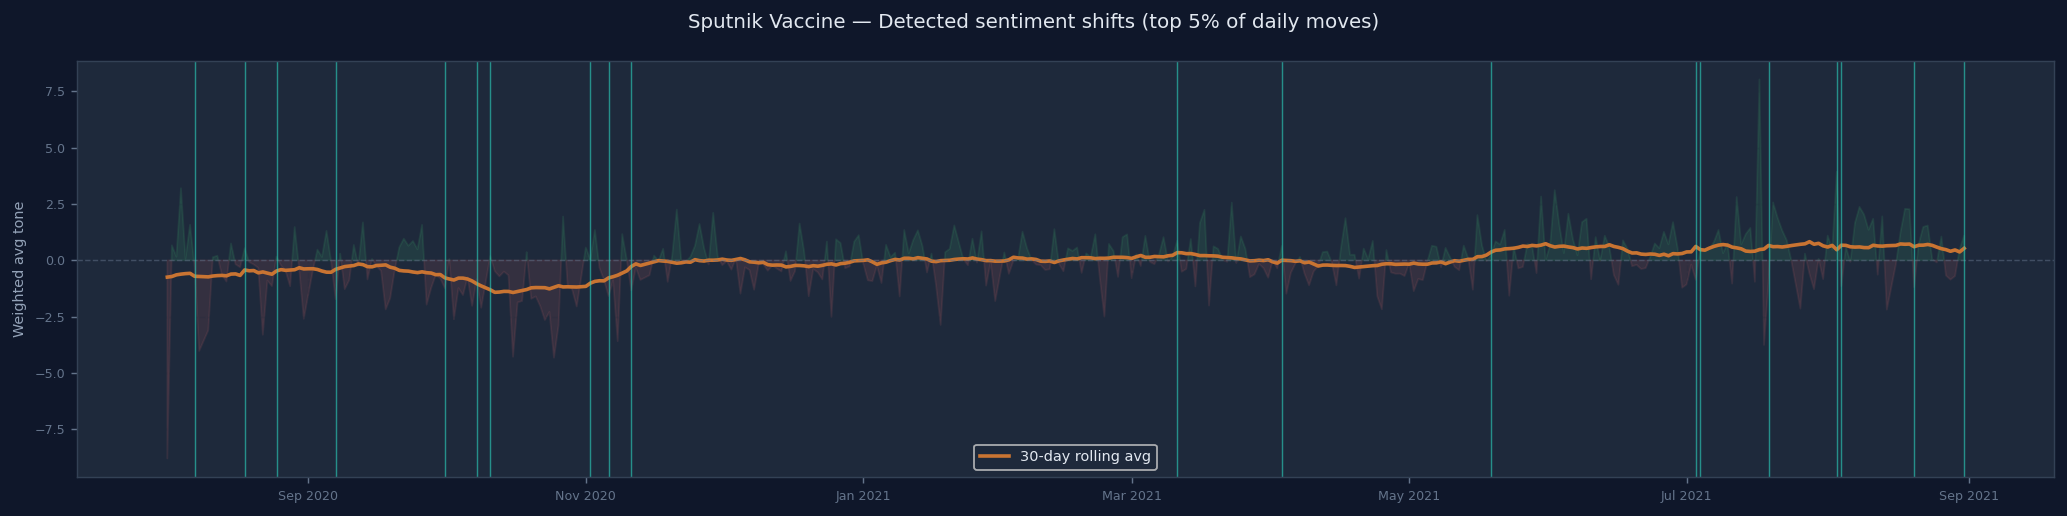

  [Sputnik Vaccine] Shift dates detected (20):  2020-08-07, 2020-08-18, 2020-08-25, 2020-09-07, 2020-10-01, 2020-10-08, 2020-10-11, 2020-11-02, 2020-11-06, 2020-11-11, 2021-03-11, 2021-04-03

[Ukraine War] Not enough dates for shift detection (15 days).



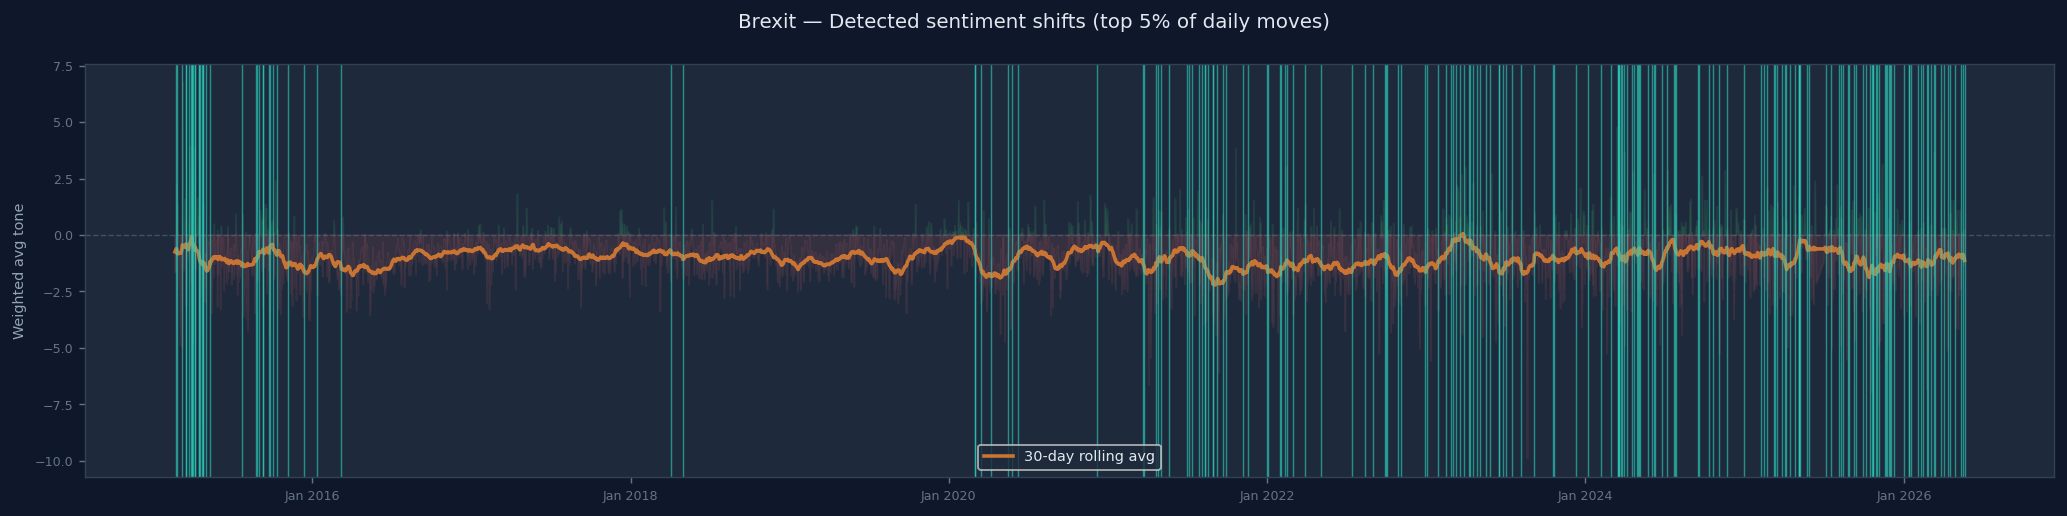

  [Brexit] Shift dates detected (203):  2015-02-23, 2015-02-25, 2015-03-09, 2015-03-17, 2015-03-18, 2015-03-25, 2015-03-29, 2015-03-30, 2015-04-01, 2015-04-03, 2015-04-07, 2015-04-08



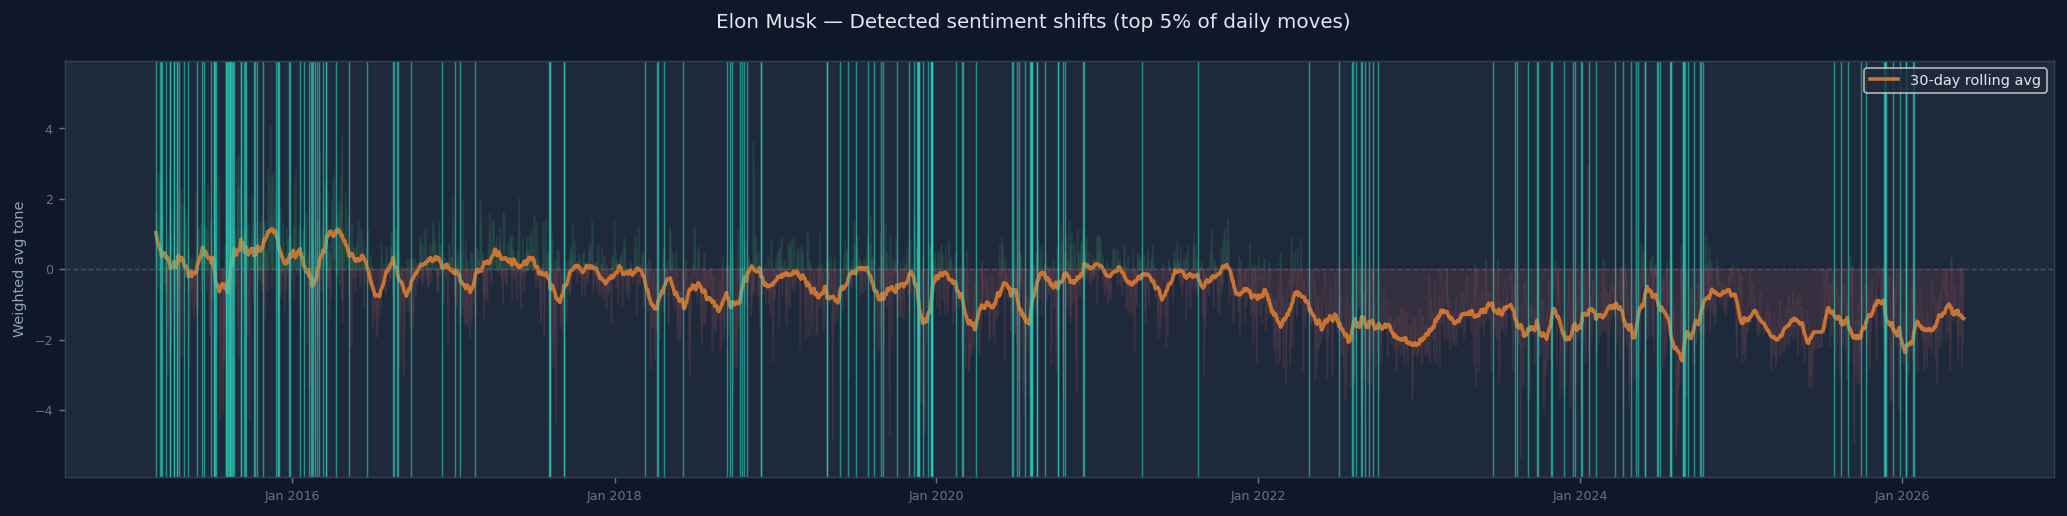

  [Elon Musk] Shift dates detected (203):  2015-02-26, 2015-03-06, 2015-03-09, 2015-03-12, 2015-03-19, 2015-03-28, 2015-03-30, 2015-04-07, 2015-04-08, 2015-04-13, 2015-04-15, 2015-04-19



In [9]:
SHIFT_THRESHOLD_PCT = 95  # flag top/bottom N-th percentile daily shifts

def detect_shifts(daily_series: pd.Series, pct: int = 95):
    """Return dates where rolling-30 sentiment shifted sharply."""
    roll = daily_series.rolling(30, center=True, min_periods=5).mean()
    delta = roll.diff().abs()
    threshold = np.percentile(delta.dropna(), pct)
    return delta[delta >= threshold].index.tolist()

for name, df in dfs.items():
    active = df[(df.article_count > 0)].dropna(subset=['avg_tone'])
    daily = (active.groupby('date')
                   .apply(lambda g: np.average(g.avg_tone, weights=g.article_count))
                   .sort_index())

    if len(daily) < 30:
        print(f'[{name}] Not enough dates for shift detection ({len(daily)} days).\n')
        continue

    shifts = detect_shifts(daily)

    roll30 = daily.rolling(30, center=True, min_periods=5).mean()

    fig, ax = plt.subplots(figsize=(16, 4))
    fig.suptitle(f'{name} — Detected sentiment shifts (top {100-SHIFT_THRESHOLD_PCT}% of daily moves)',
                 color='#e2e8f0', fontsize=11)

    ax.fill_between(daily.index, daily, 0,
                    where=daily >= 0, color=GREEN, alpha=0.1, interpolate=True)
    ax.fill_between(daily.index, daily, 0,
                    where=daily < 0,  color=RED,   alpha=0.1, interpolate=True)
    ax.plot(daily.index, roll30, color=ORANGE, linewidth=2, label='30-day rolling avg')
    ax.axhline(0, color='#64748b', linewidth=0.8, linestyle='--', alpha=0.5)

    for sd in shifts:
        ax.axvline(sd, color=TEAL, linewidth=0.8, alpha=0.6)

    ax.set_ylabel('Weighted avg tone', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f'  [{name}] Shift dates detected ({len(shifts)}): ', ', '.join([str(s.date()) for s in sorted(shifts)[:12]]))
    print()

---
## 8  Heatmap — country × time sentiment (per topic)

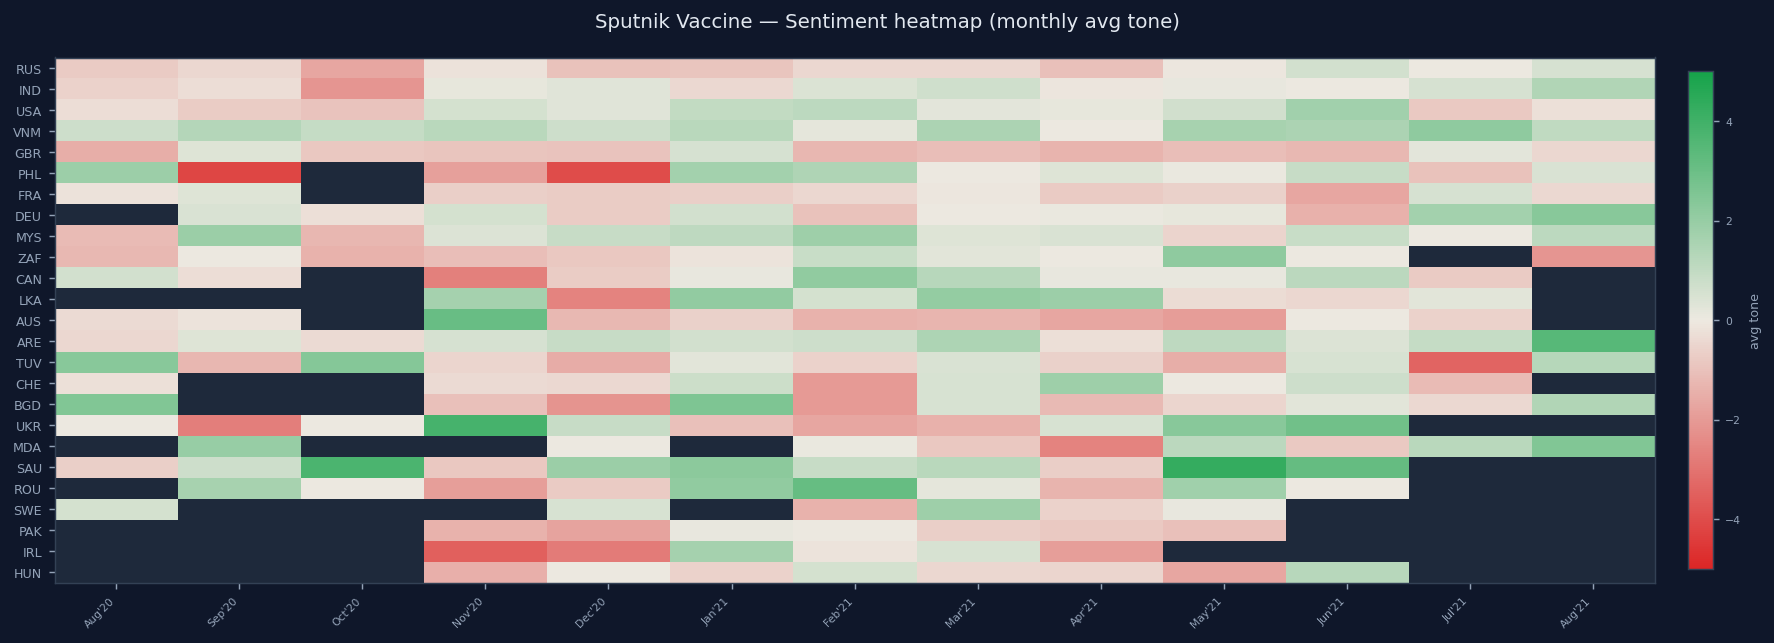

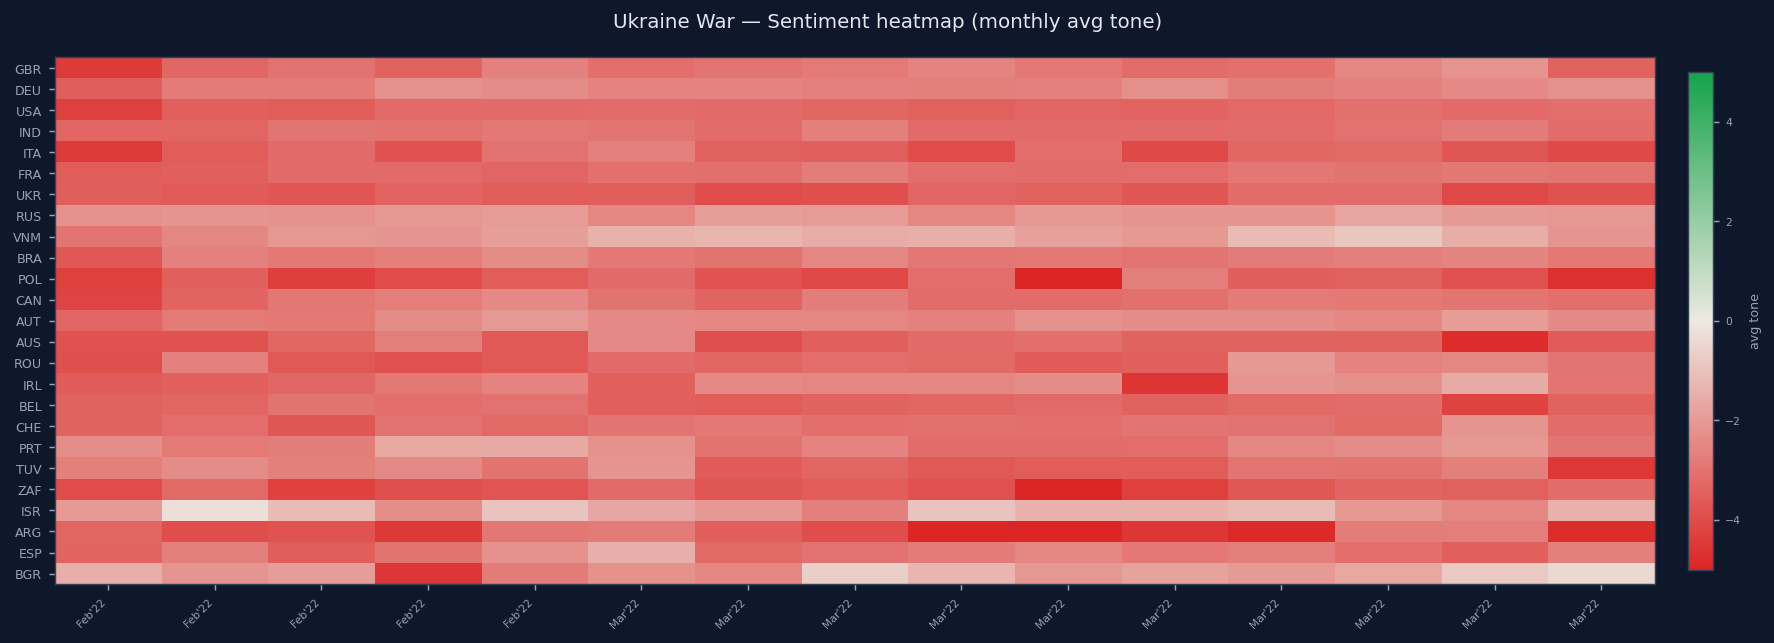

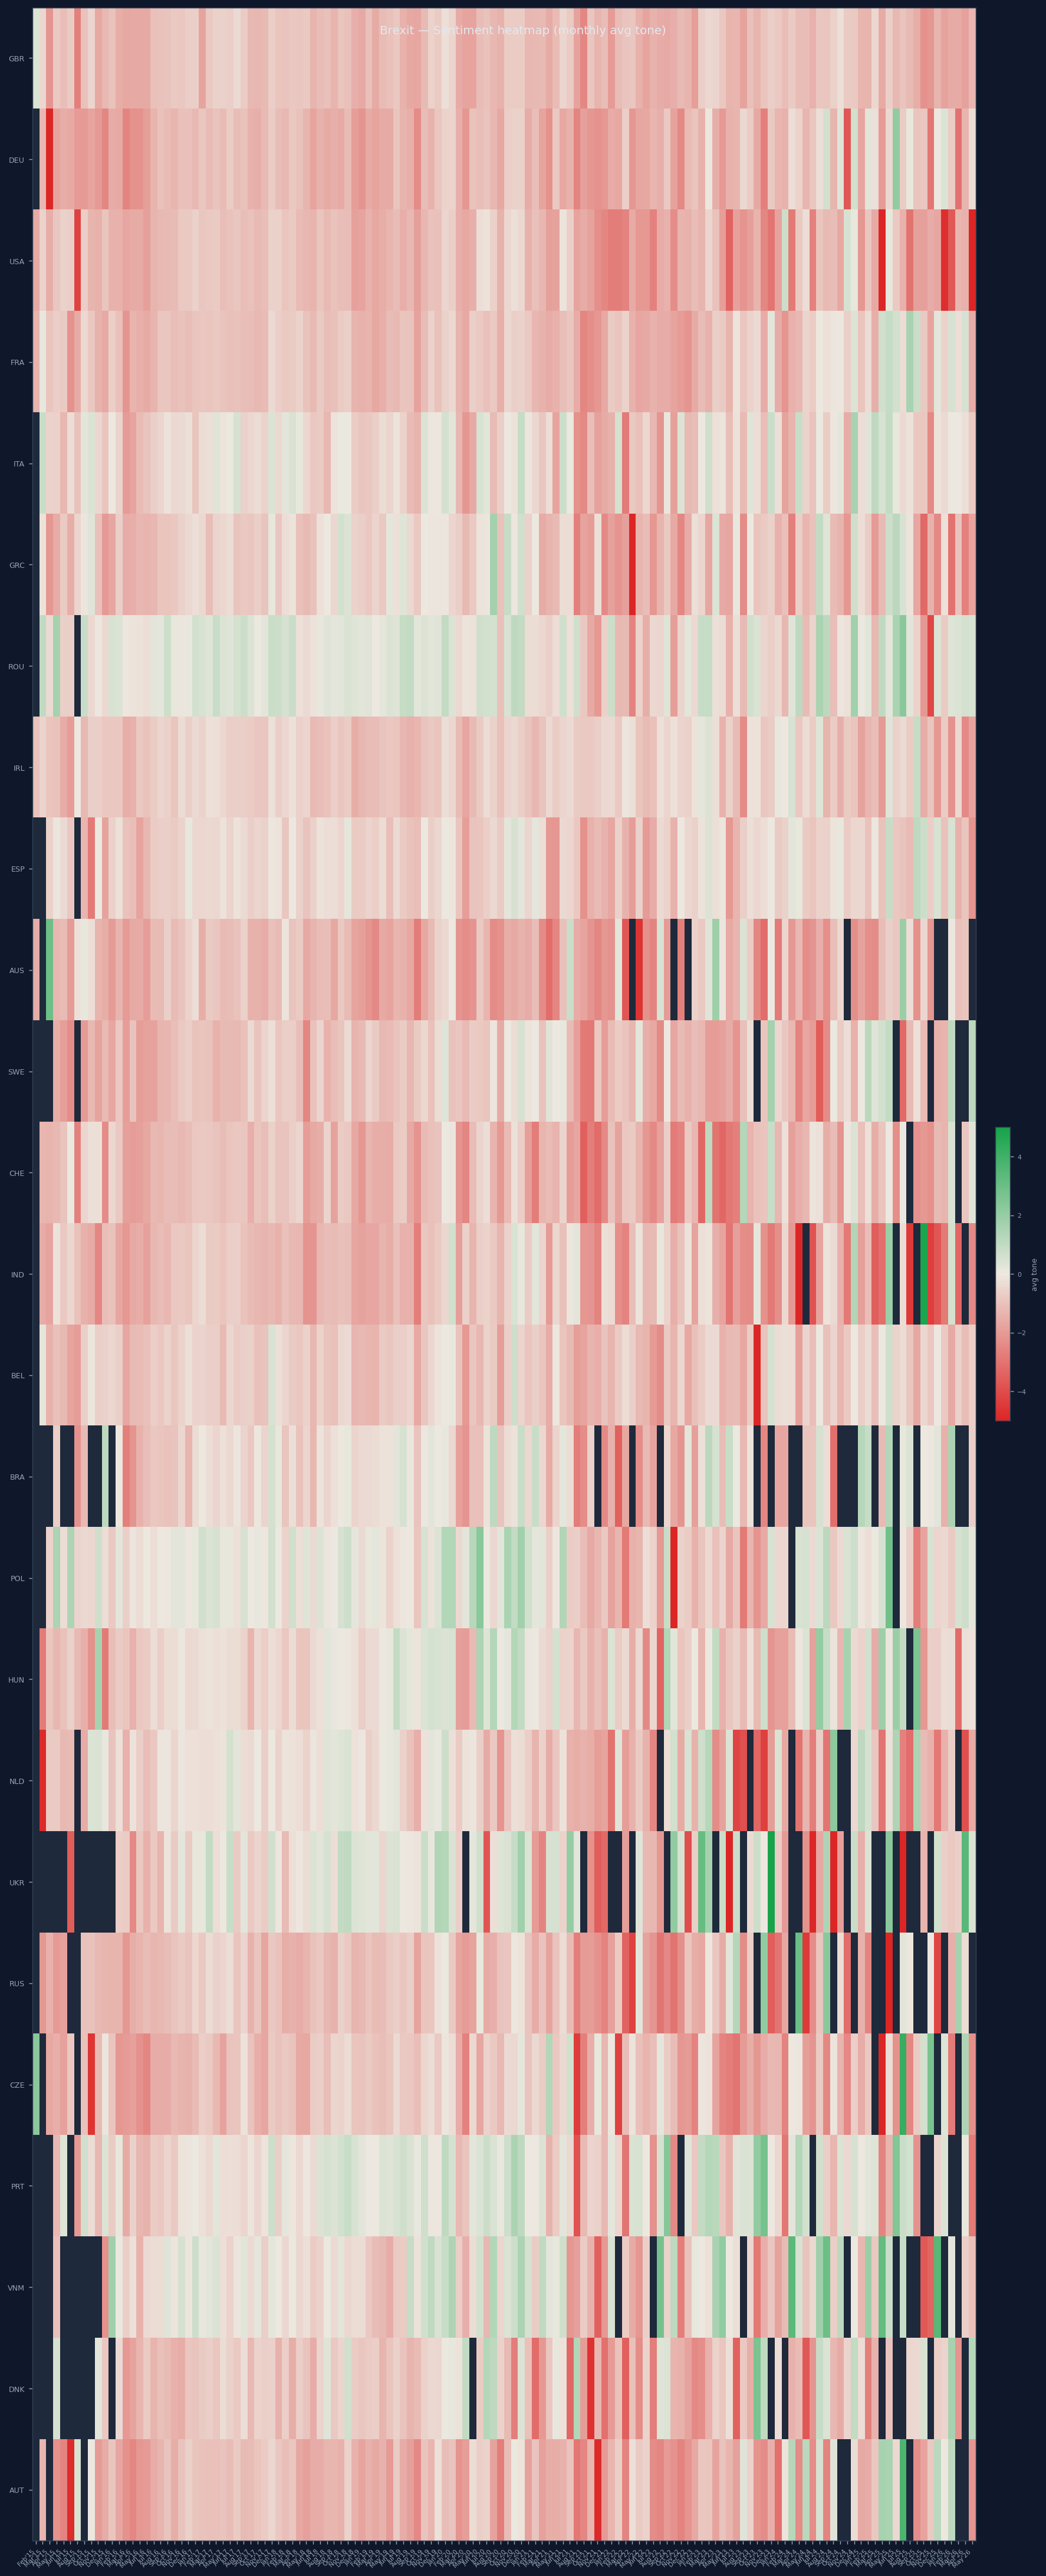

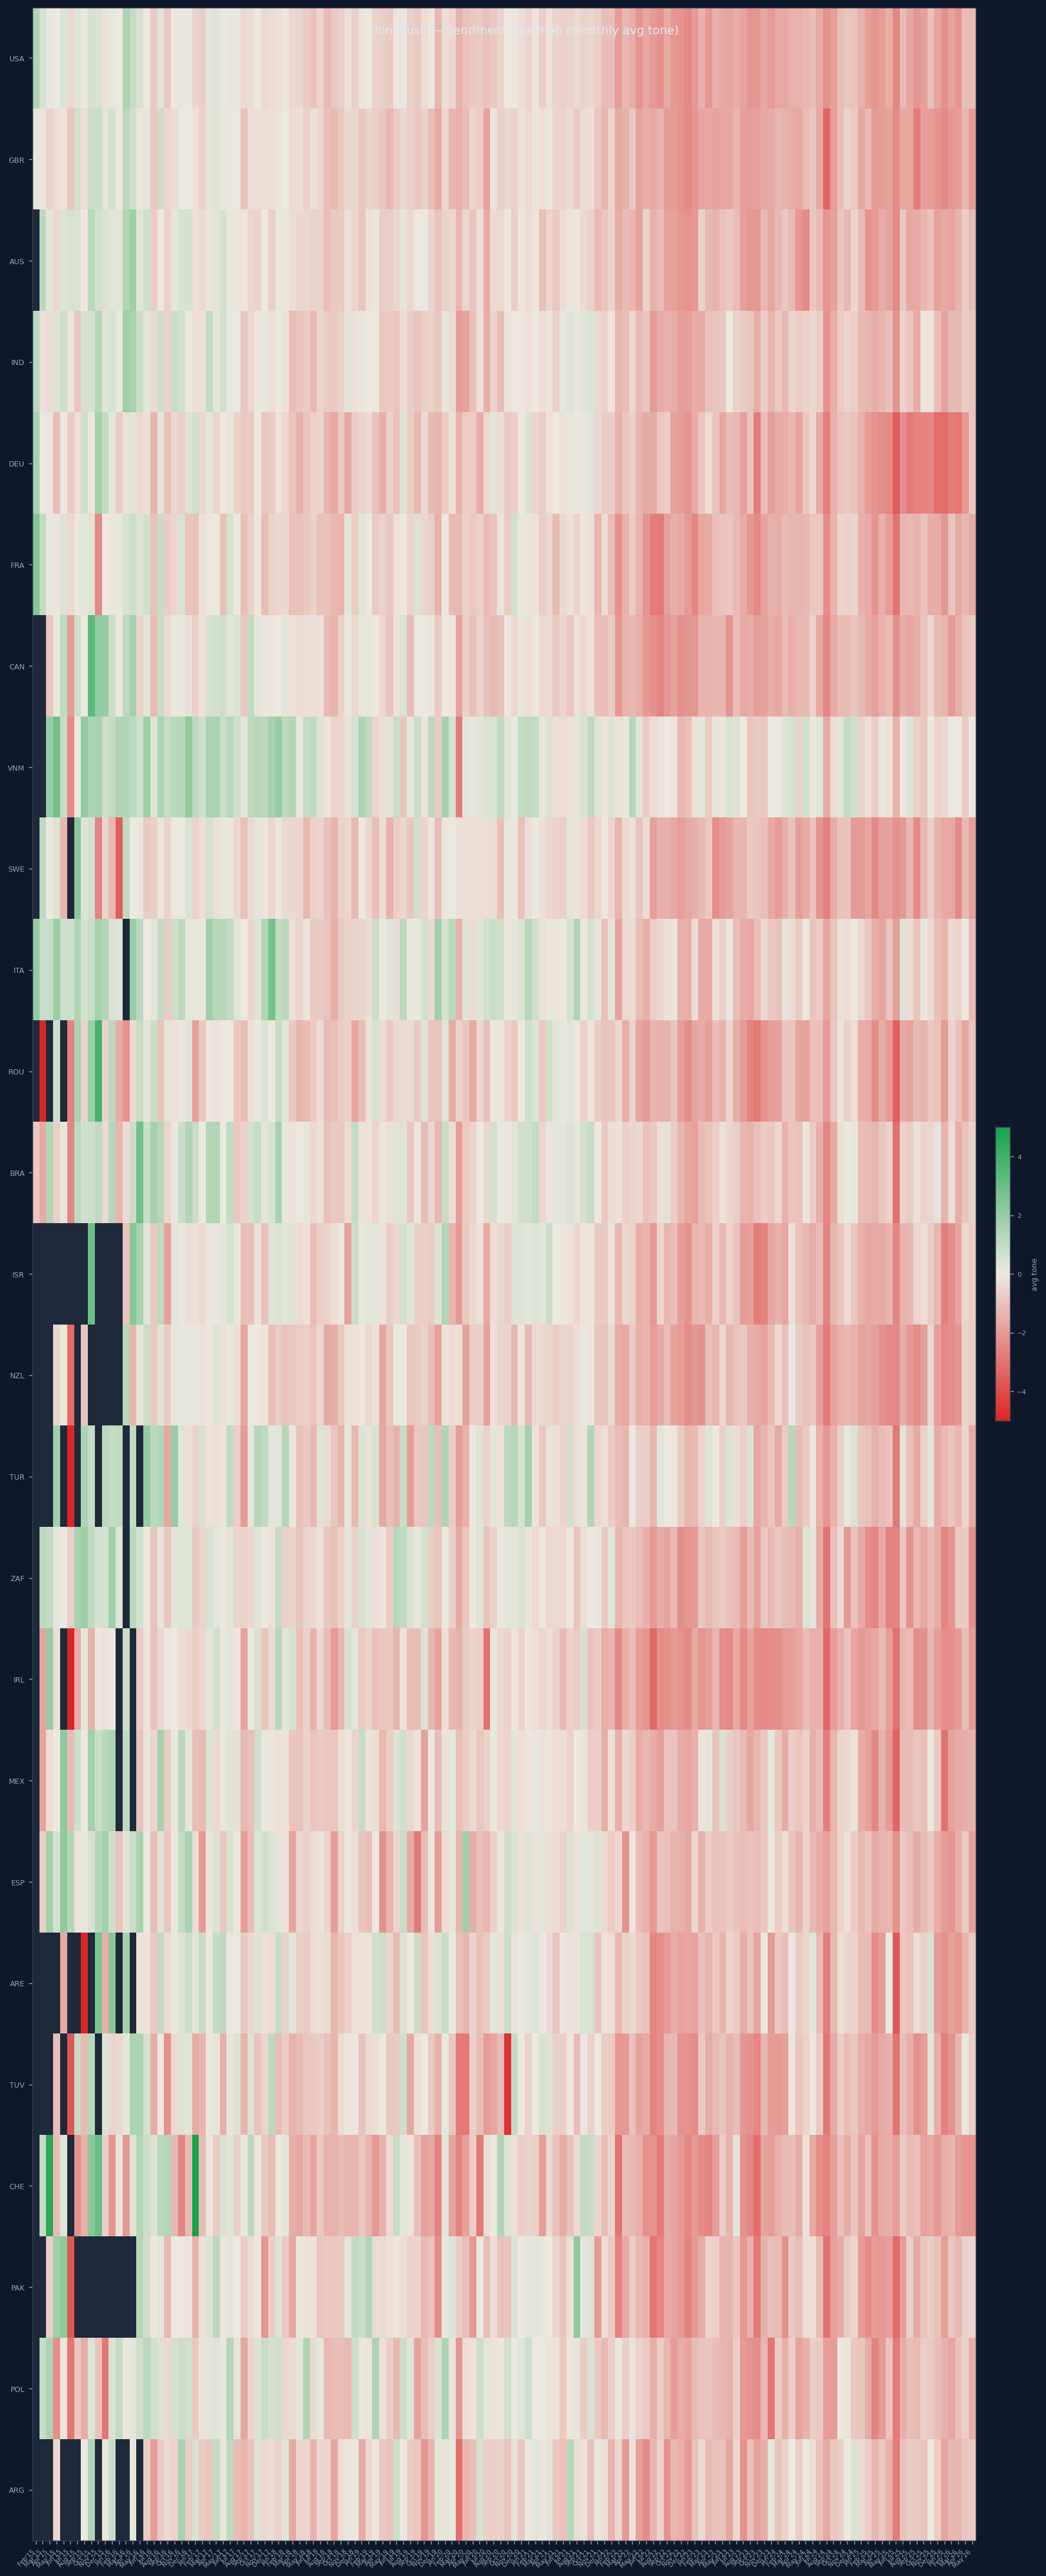

In [10]:
import matplotlib.colors as mcolors

# Custom diverging: red → beige → green
cmap = mcolors.LinearSegmentedColormap.from_list(
    'rg', ['#dc2626', '#ede9e1', '#16a34a'], N=256
)

def make_heatmap(df, title, top_n=25, resample_rule='ME'):
    active = df[(df.article_count > 0)].dropna(subset=['avg_tone'])

    # pick top_n countries by total articles
    top = (active.groupby('country_iso3')['article_count']
                 .sum().sort_values(ascending=False).head(top_n).index.tolist())
    sub = active[active.country_iso3.isin(top)].copy()

    # resample to monthly (or keep daily for short datasets)
    pivot = sub.pivot_table(index='date', columns='country_iso3',
                            values='avg_tone', aggfunc='mean')
    if resample_rule and len(pivot) > 60:
        pivot = pivot.resample(resample_rule).mean()

    pivot = pivot[top]  # preserve sorted order

    fig, ax = plt.subplots(figsize=(max(10, len(top)*0.55), max(5, len(pivot)*0.25)))
    fig.suptitle(f'{title} — Sentiment heatmap (monthly avg tone)', color='#e2e8f0', fontsize=11)

    im = ax.imshow(pivot.T.values, aspect='auto', cmap=cmap,
                   vmin=-5, vmax=5, interpolation='nearest')

    ax.set_xticks(range(len(pivot.index)))
    ax.set_xticklabels([d.strftime('%b\'%y') for d in pivot.index],
                       rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=7)
    ax.tick_params(colors='#94a3b8')

    cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
    cbar.set_label('avg tone', color='#94a3b8', fontsize=7)
    cbar.ax.tick_params(colors='#94a3b8', labelsize=6)

    plt.tight_layout()
    plt.show()

for name, df in dfs.items():
    rule = None if df.date.nunique() <= 60 else 'ME'
    make_heatmap(df, name, top_n=25, resample_rule=rule)

---
## 9  Article volume over time — how did coverage spike?

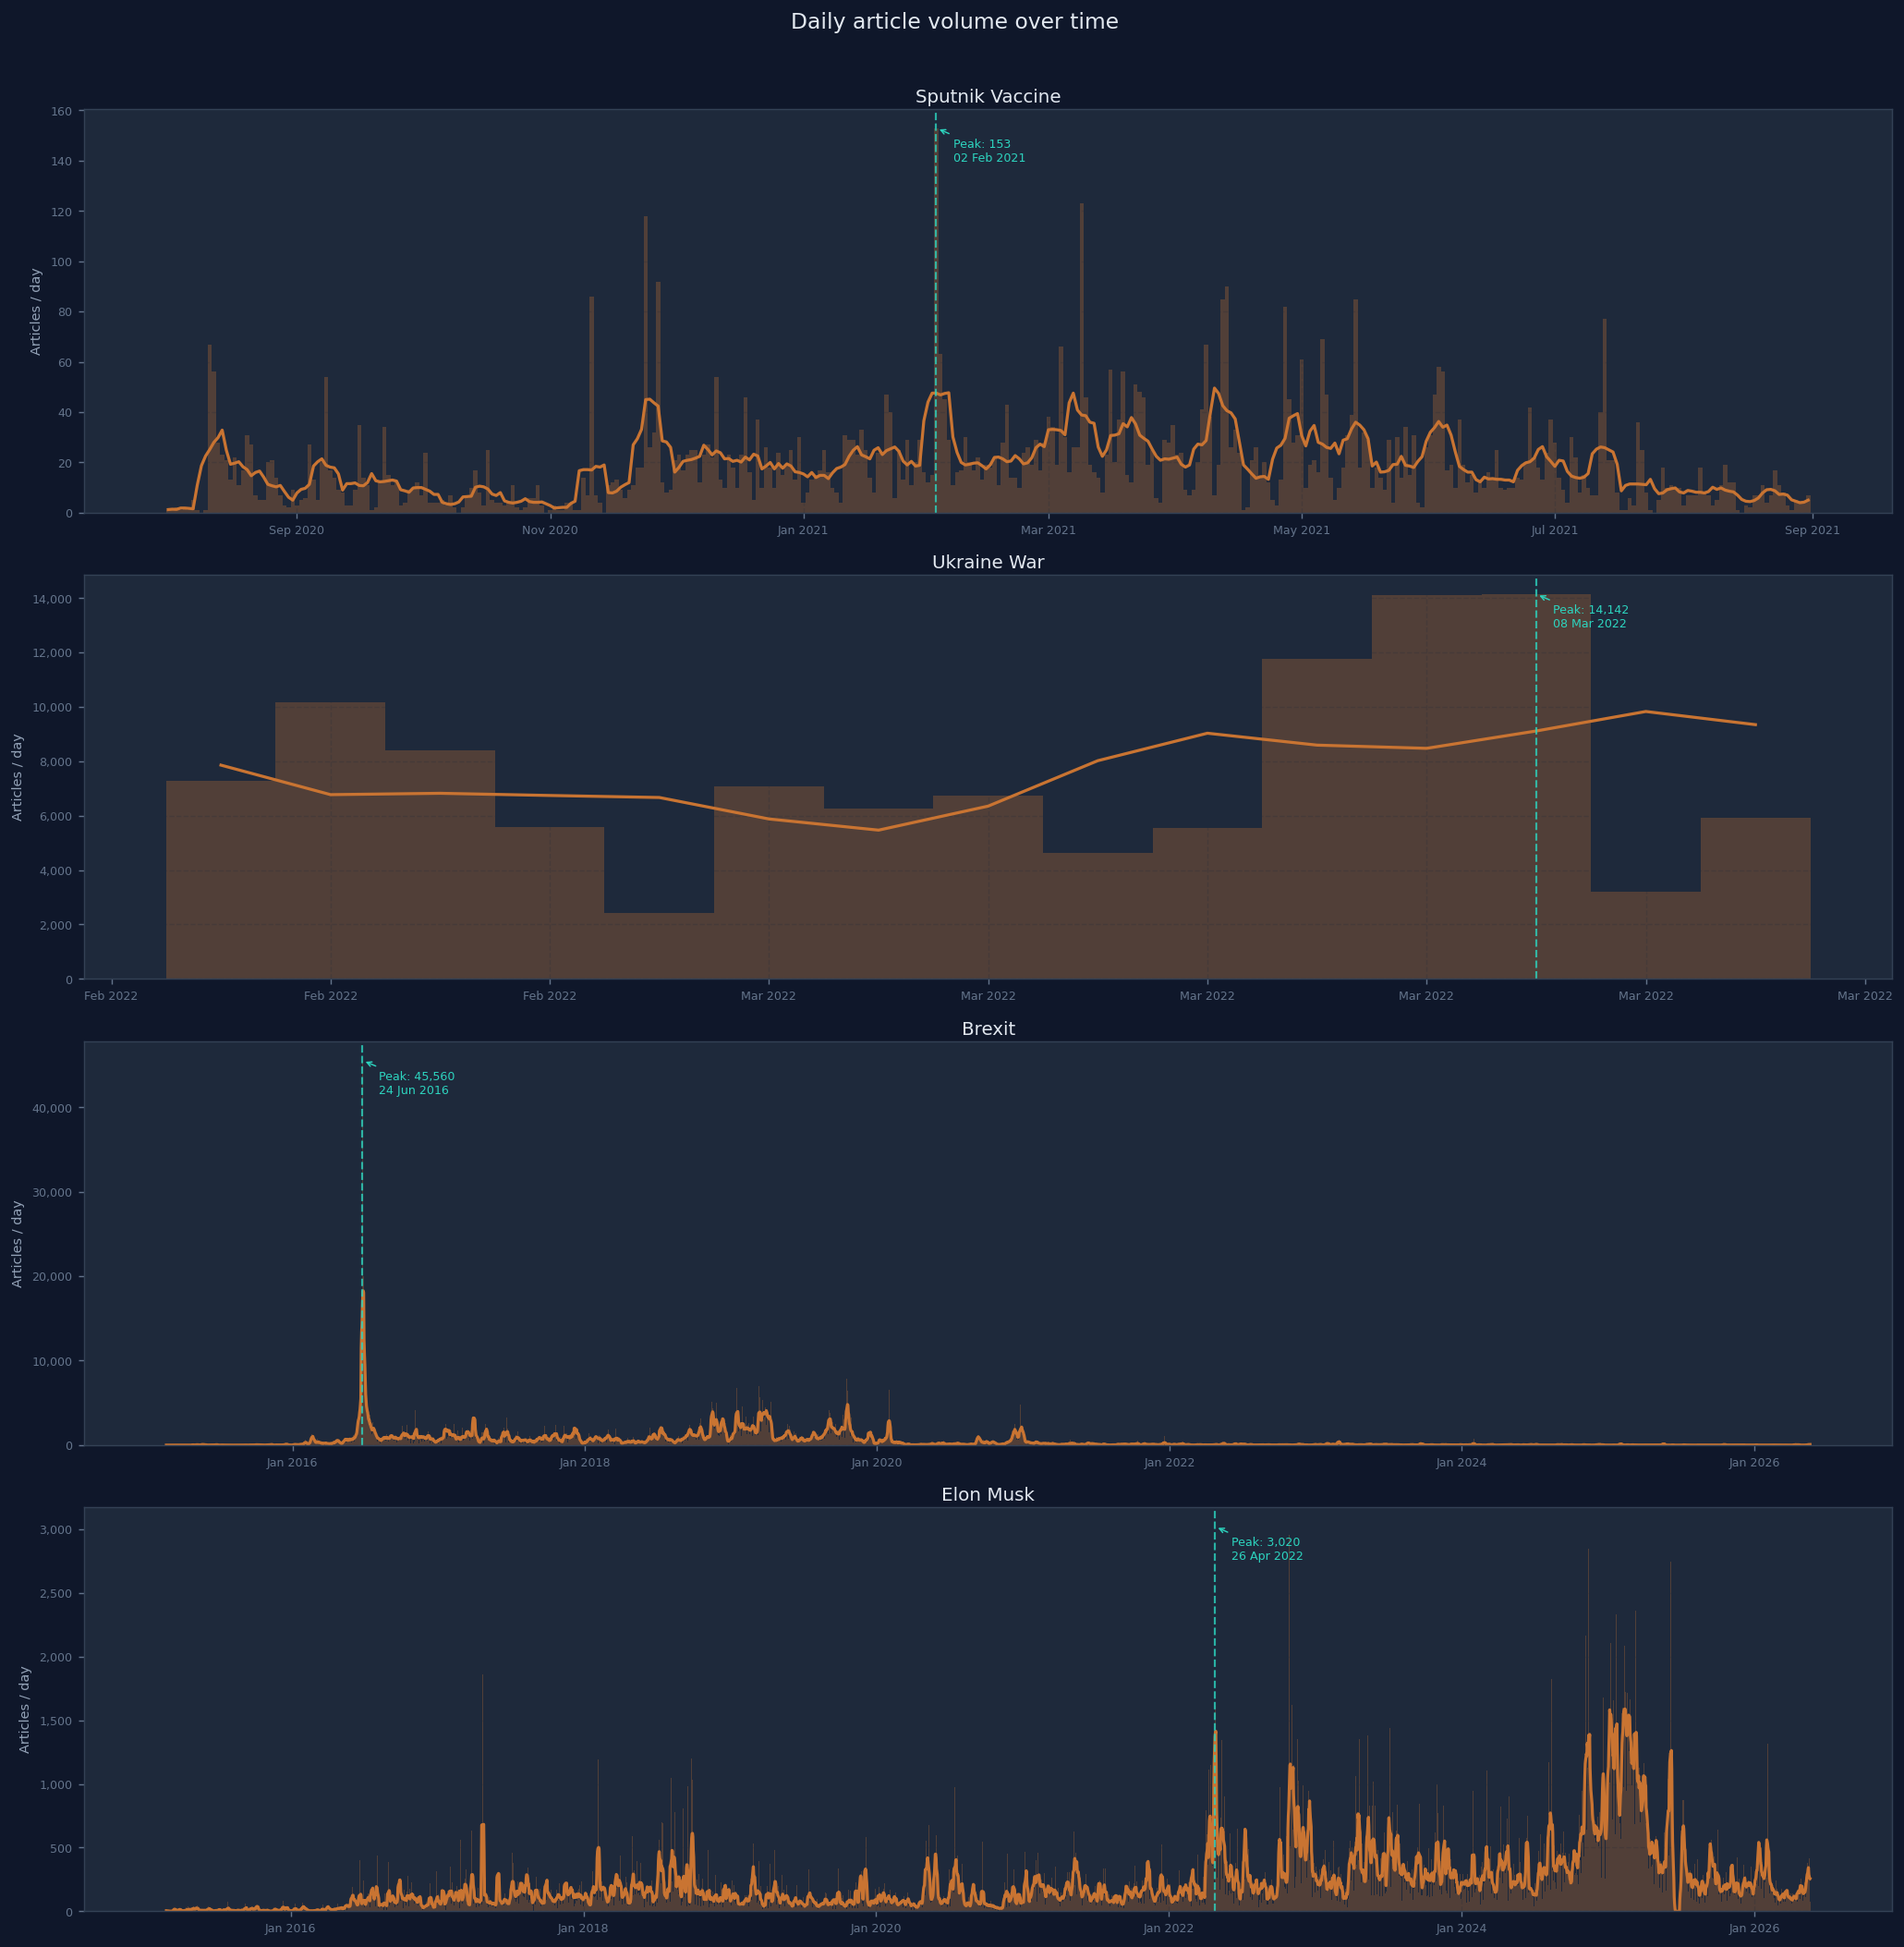

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Daily article volume over time', color='#e2e8f0', fontsize=13, y=1.01)

for ax, (name, df) in zip(axes, dfs.items()):
    daily_vol = df.groupby('date')['article_count'].sum().reset_index()
    daily_vol['roll7'] = daily_vol.article_count.rolling(7, center=True, min_periods=1).mean()

    ax.bar(daily_vol.date, daily_vol.article_count, color=ORANGE, alpha=0.3, width=1)
    ax.plot(daily_vol.date, daily_vol.roll7, color=ORANGE, linewidth=1.8)

    # mark peak
    peak_row = daily_vol.loc[daily_vol.article_count.idxmax()]
    ax.axvline(peak_row.date, color=TEAL, linewidth=1.2, linestyle='--', alpha=0.8)
    ax.annotate(f"Peak: {int(peak_row.article_count):,}\n{peak_row.date.strftime('%d %b %Y')}",
                xy=(peak_row.date, peak_row.article_count),
                xytext=(10, -20), textcoords='offset points',
                color=TEAL, fontsize=7, arrowprops=dict(arrowstyle='->', color=TEAL, lw=0.8))

    ax.set_title(name, color='#e2e8f0', fontsize=11, pad=4)
    ax.set_ylabel('Articles / day', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 10  Summary scorecard — is each dataset worth using?

In [12]:
print(f"{'Dataset':<25} {'Total articles':>14} {'Countries':>10} {'Dates':>7} "
      f"{'Global tone':>12} {'Tone std':>9} {'Verdict'}")
print('─' * 95)

for name, df in dfs.items():
    active = df[(df.article_count > 0)].dropna(subset=['avg_tone'])
    total  = df.article_count.sum()
    n_countries = active.country_iso3.nunique()
    n_dates = df.date.nunique()
    g_tone = np.average(active.avg_tone, weights=active.article_count)
    t_std  = active.avg_tone.std()

    if total > 50_000 and n_countries >= 30 and n_dates >= 100:
        verdict = '✅ STRONG'
    elif total > 5_000 and n_countries >= 10:
        verdict = '✅ USABLE'
    elif total > 500:
        verdict = '⚠️  THIN (limited dates/countries)'
    else:
        verdict = '❌ TOO SPARSE'

    print(f"{name:<25} {total:>14,} {n_countries:>10} {n_dates:>7} "
          f"{g_tone:>12.3f} {t_std:>9.3f}  {verdict}")

print()
print('Note: "avg_tone" from GDELT GKG ranges roughly -10 (very negative) to +10 (very positive).')
print('Threshold for "strong": >50k articles, ≥30 countries, ≥100 time steps.')

Dataset                   Total articles  Countries   Dates  Global tone  Tone std Verdict
───────────────────────────────────────────────────────────────────────────────────────────────
Sputnik Vaccine                    7,494         78     396        0.133     2.103  ✅ USABLE
Ukraine War                      113,291        126      15       -3.036     1.549  ✅ USABLE
Brexit                         1,997,502        155    4108       -0.947     1.949  ✅ STRONG
Elon Musk                        921,348        157    4103       -1.201     2.242  ✅ STRONG

Note: "avg_tone" from GDELT GKG ranges roughly -10 (very negative) to +10 (very positive).
Threshold for "strong": >50k articles, ≥30 countries, ≥100 time steps.
